# CIGALE AGN-Fraction Decomposition Analysis

Split out of `Paper_Results_Master.ipynb` section 9 (2026-08-05) - the CIGALE decomposition work had grown into its own large, mostly self-contained analysis and was making the master notebook unwieldy. See `docs/cigale_decomposition_findings.md` for the write-up this analysis feeds.

Section numbers (9, 9b, 9c, ...) are kept as-is from the master notebook for continuity with that doc and with `paper.tex`'s inline notes, even though this is now a standalone notebook.

This only needs a lightweight re-run of the master notebook's sections 1-2 (filters/templates + composite SED results, `df_results`) for the theory tie-back figure in 9d; everything else here is CIGALE/ZFOURGE data loaded independently.

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

# Ensure the project root is in the path to import the local package
sys.path.append(os.path.abspath('..'))

from src import config
from glass import data_io, composite_math, photometry, visualization, analysis

# PASA publication styling
plt.style.use('default')
visualization.apply_pasa_style()
os.makedirs(config.PROCESSED_DATA_DIR, exist_ok=True)

## 1. Shared Setup

Reproduces just enough of `Paper_Results_Master.ipynb` sections 1-2 to have `filters` and `df_results` (composite SED colours) available for the theory tie-back figure below - everything else in this notebook loads CIGALE/ZFOURGE data independently.

In [2]:
# Load Filters
filters = photometry.load_passbands(config.FILTER_PATHS)

# Set specific paths for templates
skirtor_dir = os.path.join(config.RAW_DATA_DIR, 'Templates', 'Skirtor')
brown_dir = os.path.join(config.RAW_DATA_DIR, 'Templates', 'Brown', '2014', 'Rest')

# Load AGN Models
agn_type1 = data_io.read_skirtor_model(skirtor_dir, **config.SKIRTOR_TYPE1_PARAMS)
agn_type2 = data_io.read_skirtor_model(skirtor_dir, **config.SKIRTOR_TYPE2_PARAMS)

# Load GALSEDATLAS (Brown) Templates
brown_templates, brown_names = data_io.read_brown_galaxy_templates(brown_dir)

In [3]:
results = []
alphas = config.ALPHA_VALUES

# Target redshifts for artificial redshifting
z_ugr = 3.0 # Within the U-dropout target range of 2.6 < z < 3.6
z_irac = 0.0 # Restframe for standard Lacy wedge demo

for t_idx, gal_sed in enumerate(brown_templates):
    gal_name = brown_names[t_idx]
    print(f"Processing template {t_idx+1}/{len(brown_templates)}: {gal_name}")
    
    for agn_name, agn_model in [('Type1', agn_type1), ('Type2', agn_type2)]:
        for alpha in alphas:
            comp_sed = composite_math.create_composite_sed(agn_model, gal_sed, alpha)
            
            # Calculate UVJ (restframe)
            uv, vj = photometry.calculate_UVJ_colours(comp_sed, filters['U'], filters['V'], filters['J'])
            
            # Calculate ugr (redshifted to z=3.0)
            ug, gr = photometry.calculate_ugr_colours(comp_sed, filters['u'], filters['g'], filters['r'], redshift=z_ugr)
            
            # Calculate IRAC (restframe)
            f5836, f8045 = photometry.calculate_irac_colours(comp_sed, filters['3.6'], filters['4.5'], filters['5.8'], filters['8.0'], redshift=z_irac)
            
            results.append({
                'Template': gal_name,
                'AGN_Type': agn_name,
                'Alpha': alpha,
                'U-V': uv,
                'V-J': vj,
                'u-g': ug,
                'g-r': gr,
                'f5836': f5836,
                'f8045': f8045
            })

df_results = pd.DataFrame(results)
print("Processed all composite combinations.")

Processing template 1/128: Arp_118
Processing template 2/128: Arp_256_N
Processing template 3/128: Arp_256_S
Processing template 4/128: CGCG_049-057
Processing template 5/128: CGCG_436-030


Processing template 6/128: CGCG_453-062
Processing template 7/128: Haro_06
Processing template 8/128: IC_0691
Processing template 9/128: IC_0860
Processing template 10/128: IC_0883


Processing template 11/128: IC_4051
Processing template 12/128: IC_4553
Processing template 13/128: IC_5298
Processing template 14/128: III_Zw_035
Processing template 15/128: II_Zw_096


Processing template 16/128: IRAS_08572+3915
Processing template 17/128: IRAS_17208-0014
Processing template 18/128: Mrk_0331
Processing template 19/128: Mrk_0475
Processing template 20/128: Mrk_0930
Processing template 21/128: Mrk_1450


Processing template 22/128: Mrk_1490
Processing template 23/128: Mrk_33
Processing template 24/128: NGC_0337
Processing template 25/128: NGC_0474
Processing template 26/128: NGC_0520
Processing template 27/128: NGC_0584


...

Processing template 109/128: NGC_7674
Processing template 110/128: NGC_7679
Processing template 111/128: NGC_7714
Processing template 112/128: NGC_7771
Processing template 113/128: UGCA_166


Processing template 114/128: UGCA_208
Processing template 115/128: UGCA_219
Processing template 116/128: UGCA_410
Processing template 117/128: UGC_04881
Processing template 118/128: UGC_05101


Processing template 119/128: UGC_06665
Processing template 120/128: UGC_06850
Processing template 121/128: UGC_08335_NW
Processing template 122/128: UGC_08335_SE
Processing template 123/128: UGC_08696


Processing template 124/128: UGC_09618_N
Processing template 125/128: UGC_09618
Processing template 126/128: UGC_09618_S
Processing template 127/128: UGC_12150
Processing template 128/128: UM_461


Processed all composite combinations.


## 9. CIGALE Decomposed Population Analysis (Fig 9, 10, 11)

Final observational support: analyzing the UVJ shift of the entire ZFOURGE population when AGN light is removed via CIGALE SED decomposition.

C:\Users\uqmhooym\AppData\Local\Temp\ipykernel_20800\3872384203.py:5: DtypeWarning: Columns (0: Use2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_cig = pd.read_csv(cigale_csv)


AGN-hosting galaxies (fracAGN > 0.0): 6509 of 10876
Quiescent: shift = (+0.001, +0.041)  n=496
Star-forming: shift = (-0.035, +0.036)  n=5551
Dusty: shift = (-0.016, +0.125)  n=462


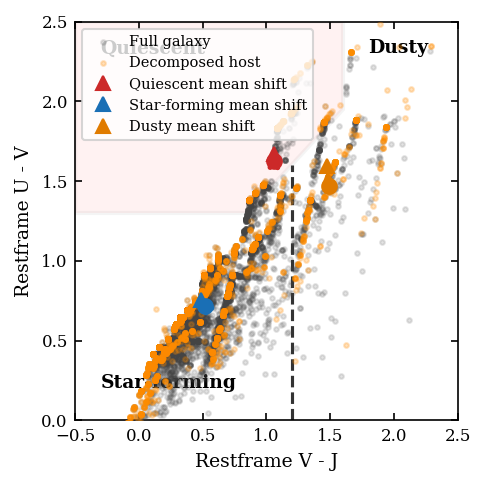

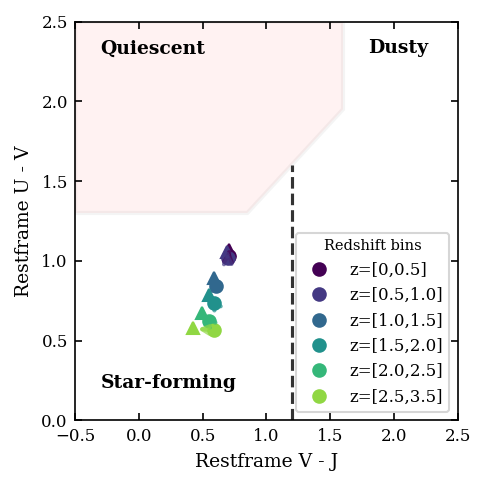

In [4]:
# Load CIGALE summary table
cigale_csv = os.path.join('..\datasets', 'full_zfourge_decomposed', 'zfourge_full_final.csv')
agn_frac_csv = os.path.join('..\datasets', 'full_zfourge_decomposed', 'agn_fractions.csv')
if os.path.exists(cigale_csv):
    df_cig = pd.read_csv(cigale_csv)
    z_col = 'zpk_x' if 'zpk_x' in df_cig.columns else 'zpk'

    # Attach CIGALE best-fit AGN fraction (agn.fracAGN) to each galaxy.
    # The cache is built from the per-galaxy best-model FITS headers if not present.
    if not os.path.exists(agn_frac_csv):
        from astropy.io import fits as _fits
        _rows = []
        for _gid, _field in zip(df_cig['ID'], df_cig['field']):
            _path = os.path.join('..\datasets', 'full_zfourge_decomposed',
                                 f"{_field.lower()}_best_models_fits",
                                 f"{_gid.split('_', 1)[1]}_best_model.fits")
            if os.path.exists(_path):
                _rows.append({'ID': _gid, 'fracAGN': float(_fits.getheader(_path, 1)['agn.fracAGN'])})
        pd.DataFrame(_rows).to_csv(agn_frac_csv, index=False)
    df_cig = df_cig.merge(pd.read_csv(agn_frac_csv), on='ID', how='left')

    # Only galaxies with a non-zero best-fit AGN fraction can shift when the AGN
    # is removed; galaxies with fracAGN = 0 have identical full/decomposed colours
    # and dilute the mean shift. Raise the threshold (e.g. 0.1) for a stricter cut.
    AGN_FRAC_MIN = 0.0
    df_agn = df_cig[df_cig['fracAGN'] > AGN_FRAC_MIN]
    print(f"AGN-hosting galaxies (fracAGN > {AGN_FRAC_MIN}): {len(df_agn)} of {len(df_cig)}")

    # Fig 9: Full + decomposed scatter with bold per-region mean shift arrows
    fig, ax = plt.subplots(figsize=visualization.PASA_SQ)
    visualization.plot_uvj_diagram([], [], ax=ax, title="")

    ax.scatter(df_agn['VJ_Full'],       df_agn['UV_Full'],       c='#444444',   s=5, alpha=0.15, label='Full galaxy',     zorder=3)
    ax.scatter(df_agn['VJ_Decomposed'], df_agn['UV_Decomposed'], c='darkorange', s=5, alpha=0.25, label='Decomposed host', zorder=3)

    # Bold mean vectors per UVJ region (classified by full-galaxy position)
    classifications_full = photometry.classify_uvj(df_agn['VJ_Full'], df_agn['UV_Full'])
    region_colors = {0: '#CC2929', 1: '#1A6FB5', 2: '#E07B00'}
    region_names  = {0: 'Quiescent', 1: 'Star-forming', 2: 'Dusty'}
    for cid in [0, 1, 2]:
        mask = classifications_full == cid
        if mask.sum() < 3: continue
        mvj_f = df_agn.loc[mask, 'VJ_Full'].mean()
        muv_f = df_agn.loc[mask, 'UV_Full'].mean()
        mvj_d = df_agn.loc[mask, 'VJ_Decomposed'].mean()
        muv_d = df_agn.loc[mask, 'UV_Decomposed'].mean()
        print(f"{region_names[cid]}: shift = ({mvj_d - mvj_f:+.3f}, {muv_d - muv_f:+.3f})  n={mask.sum()}")
        ax.annotate('', xy=(mvj_d, muv_d), xytext=(mvj_f, muv_f),
                    arrowprops=dict(arrowstyle='->', color=region_colors[cid], lw=2.5))
        ax.plot(mvj_f, muv_f, 'o', color=region_colors[cid], markersize=7, zorder=6)
        ax.plot(mvj_d, muv_d, '^', color=region_colors[cid], markersize=7, zorder=6,
                label=f'{region_names[cid]} mean shift')

    ax.legend(loc='upper left', fontsize=7)
    plt.tight_layout()
    fig.savefig(os.path.join(config.PROCESSED_DATA_DIR, 'UVJ_CIGALE_FullDecomp_Vectors.pdf'), dpi=300, bbox_inches='tight')
    plt.show()

    # Fig 11: Redshift Divergence — mean full vs decomposed positions per redshift bin
    bins = [[0, 0.5], [0.5, 1.0], [1.0, 1.5], [1.5, 2.0], [2.0, 2.5], [2.5, 3.5]]
    fig, ax = plt.subplots(figsize=visualization.PASA_SQ)
    visualization.plot_uvj_diagram([], [], ax=ax, title="")
    cmap = plt.cm.viridis
    for i, (z_min, z_max) in enumerate(bins):
        sub = df_agn[(df_agn[z_col] >= z_min) & (df_agn[z_col] < z_max)]
        if len(sub) < 5: continue
        mvj_f, muv_f = sub['VJ_Full'].mean(), sub['UV_Full'].mean()
        mvj_d, muv_d = sub['VJ_Decomposed'].mean(), sub['UV_Decomposed'].mean()
        c = cmap(i / len(bins))
        ax.plot(mvj_f, muv_f, 'o', color=c, markersize=6, label=f'z=[{z_min},{z_max}]')
        ax.plot(mvj_d, muv_d, '^', color=c, markersize=6)
        ax.annotate('', xy=(mvj_d, muv_d), xytext=(mvj_f, muv_f),
                    arrowprops=dict(arrowstyle="->", color=c, lw=2, alpha=0.7))
    ax.legend(loc='lower right', title="Redshift bins", title_fontsize=7)
    plt.tight_layout()
    fig.savefig(os.path.join(config.PROCESSED_DATA_DIR, 'UVJ_agn_evolution_CIGALE_ZFOURGE_comparison_redshift.pdf'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("CIGALE summary table not found.")

### 9b. Decomposition shift as a function of AGN fraction

Diagnostic figures splitting the CIGALE decomposition shift into disjoint `fracAGN` bins (the CIGALE grid is discrete: 0, 0.01, 0.1, ..., 0.9, 0.99). Each bin is an independent sample, so the growth of the UVJ shift with AGN contribution is directly readable. Outputs are saved to `outputs/fracAGN_diagnostics/`. Requires the section 9 cell above to have run (provides `df_cig` with `fracAGN` merged).

       Bin         Region      dVJ      dUV  |shift|      n
  0.01–0.1      Quiescent   +0.003   +0.031    0.031    295
  0.01–0.1   Star-forming   +0.003   +0.026    0.026   2337
  0.01–0.1          Dusty   +0.033   +0.113    0.117    310
   0.2–0.3      Quiescent   +0.001   +0.064    0.064    152
   0.2–0.3   Star-forming   -0.013   +0.054    0.056   1584
   0.2–0.3          Dusty   +0.072   +0.246    0.257     90
   0.4–0.5      Quiescent   -0.009   +0.039    0.040     37
   0.4–0.5   Star-forming   -0.061   +0.058    0.084    857
   0.4–0.5          Dusty   -0.004   +0.164    0.164     31
  0.6–0.99      Quiescent   -0.004   +0.002    0.004     12
  0.6–0.99   Star-forming   -0.170   +0.005    0.170    773
  0.6–0.99          Dusty   -0.768   -0.142    0.781     31


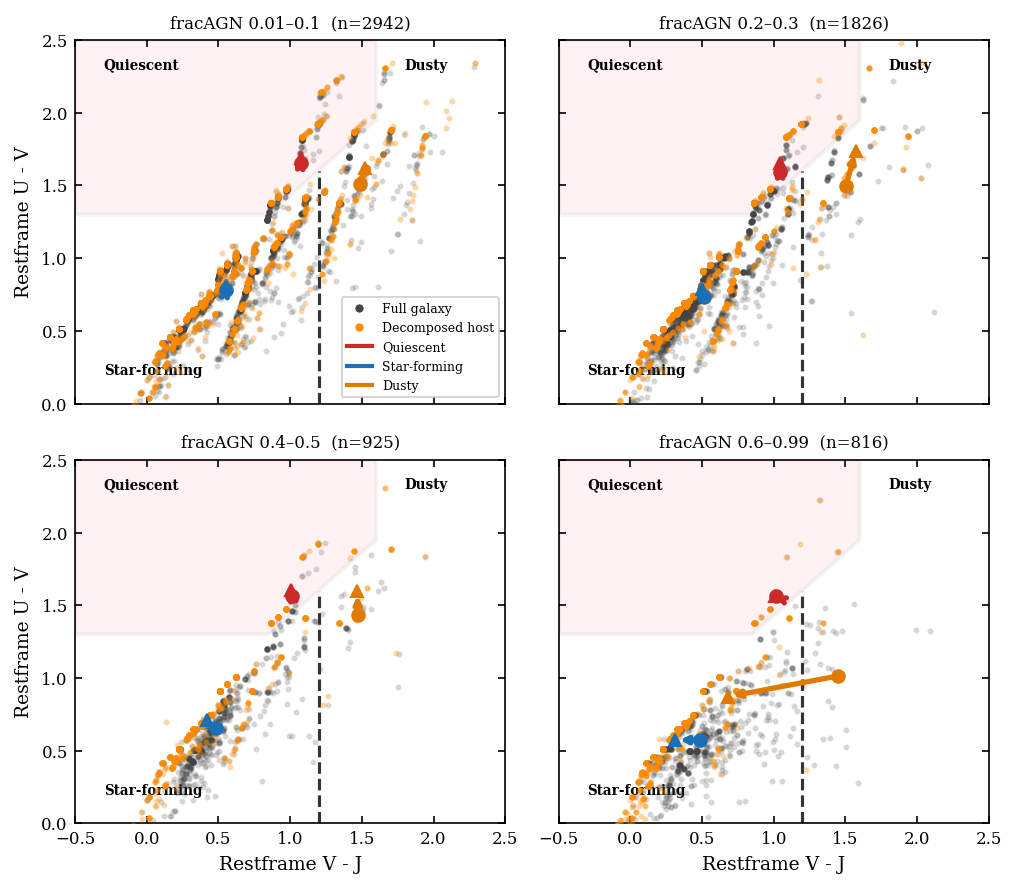

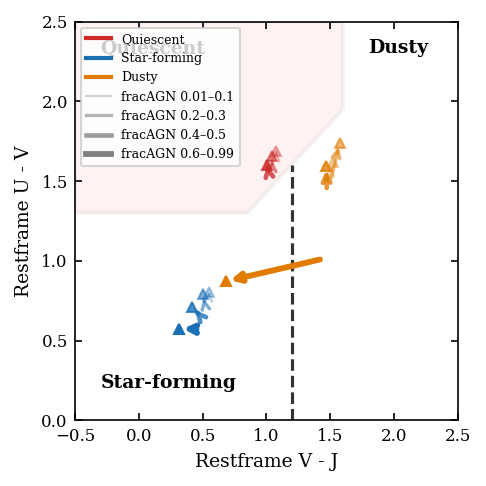

In [5]:
# Disjoint fracAGN bins (fracAGN is a discrete CIGALE grid: 0, 0.01, 0.1, ..., 0.9, 0.99;
# edges sit between grid values so float comparison is safe)
FRAC_BINS = [(0.005, 0.15, '0.01–0.1'), (0.15, 0.35, '0.2–0.3'),
             (0.35, 0.55, '0.4–0.5'),   (0.55, 1.00, '0.6–0.99')]
frac_out_dir = os.path.join(config.PROCESSED_DATA_DIR, 'fracAGN_diagnostics')
os.makedirs(frac_out_dir, exist_ok=True)

region_colors = {0: '#CC2929', 1: '#1A6FB5', 2: '#E07B00'}
region_names  = {0: 'Quiescent', 1: 'Star-forming', 2: 'Dusty'}

def region_mean_shifts(d, min_n=3):
    """Mean full/decomposed UVJ positions per region (classified on full colours)."""
    cls = photometry.classify_uvj(d['VJ_Full'], d['UV_Full'])
    out = {}
    for cid in [0, 1, 2]:
        m = cls == cid
        if m.sum() < min_n: continue
        out[cid] = (d.loc[m, 'VJ_Full'].mean(),       d.loc[m, 'UV_Full'].mean(),
                    d.loc[m, 'VJ_Decomposed'].mean(), d.loc[m, 'UV_Decomposed'].mean(),
                    int(m.sum()))
    return out

# Fig A: 2x2 UVJ grid — scatter + per-region mean shift arrows for each fracAGN bin
fig, axes = plt.subplots(2, 2, figsize=(6.85, 6.0), sharex=True, sharey=True)
print(f"{'Bin':>10} {'Region':>14} {'dVJ':>8} {'dUV':>8} {'|shift|':>8} {'n':>6}")
for ax, (lo, hi, label) in zip(axes.flat, FRAC_BINS):
    d = df_cig[(df_cig['fracAGN'] > lo) & (df_cig['fracAGN'] <= hi)]
    visualization.plot_uvj_diagram([], [], ax=ax, title="")
    ax.scatter(d['VJ_Full'],       d['UV_Full'],       c='#444444',    s=4, alpha=0.15, zorder=3)
    ax.scatter(d['VJ_Decomposed'], d['UV_Decomposed'], c='darkorange', s=4, alpha=0.25, zorder=3)
    for cid, (vj_f, uv_f, vj_d, uv_d, n) in region_mean_shifts(d).items():
        print(f"{label:>10} {region_names[cid]:>14} {vj_d - vj_f:>+8.3f} {uv_d - uv_f:>+8.3f} "
              f"{np.hypot(vj_d - vj_f, uv_d - uv_f):>8.3f} {n:>6}")
        ax.annotate('', xy=(vj_d, uv_d), xytext=(vj_f, uv_f),
                    arrowprops=dict(arrowstyle='->', color=region_colors[cid], lw=2.5))
        ax.plot(vj_f, uv_f, 'o', color=region_colors[cid], markersize=6, zorder=6)
        ax.plot(vj_d, uv_d, '^', color=region_colors[cid], markersize=6, zorder=6)
    ax.set_title(f'fracAGN {label}  (n={len(d)})', fontsize=8)
    for txt in ax.texts:
        txt.set_fontsize(6.5)

legend_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor='#444444', markersize=5, label='Full galaxy'),
                  Line2D([0], [0], marker='o', color='w', markerfacecolor='darkorange', markersize=5, label='Decomposed host')] + \
                 [Line2D([0], [0], color=region_colors[cid], lw=2, label=region_names[cid]) for cid in [0, 1, 2]]
axes.flat[0].legend(handles=legend_handles, loc='lower right', fontsize=6)
for ax in axes[0, :]: ax.set_xlabel('')
for ax in axes[:, 1]: ax.set_ylabel('')
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_FullDecomp_Vectors_fracAGN_bins.pdf'), dpi=300, bbox_inches='tight')
plt.show()

# Fig B: single-axis summary — per-region mean shift arrows for all bins on one diagram
fig, ax = plt.subplots(figsize=visualization.PASA_SQ)
visualization.plot_uvj_diagram([], [], ax=ax, title="")
bin_alphas = np.linspace(0.35, 1.0, len(FRAC_BINS))
bin_lws    = np.linspace(1.0, 2.8, len(FRAC_BINS))
for i, (lo, hi, label) in enumerate(FRAC_BINS):
    d = df_cig[(df_cig['fracAGN'] > lo) & (df_cig['fracAGN'] <= hi)]
    for cid, (vj_f, uv_f, vj_d, uv_d, n) in region_mean_shifts(d, min_n=20).items():
        ax.annotate('', xy=(vj_d, uv_d), xytext=(vj_f, uv_f),
                    arrowprops=dict(arrowstyle='->', color=region_colors[cid],
                                    lw=bin_lws[i], alpha=bin_alphas[i]))
        ax.plot(vj_d, uv_d, '^', color=region_colors[cid], markersize=5,
                alpha=bin_alphas[i], zorder=6)
legend_handles = [Line2D([0], [0], color=region_colors[cid], lw=2, label=region_names[cid]) for cid in [0, 1, 2]] + \
                 [Line2D([0], [0], color='gray', lw=bin_lws[i], alpha=bin_alphas[i], label=f'fracAGN {b[2]}')
                  for i, b in enumerate(FRAC_BINS)]
ax.legend(handles=legend_handles, loc='upper left', fontsize=6)
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_FullDecomp_Vectors_fracAGN_summary.pdf'), dpi=300, bbox_inches='tight')
plt.show()

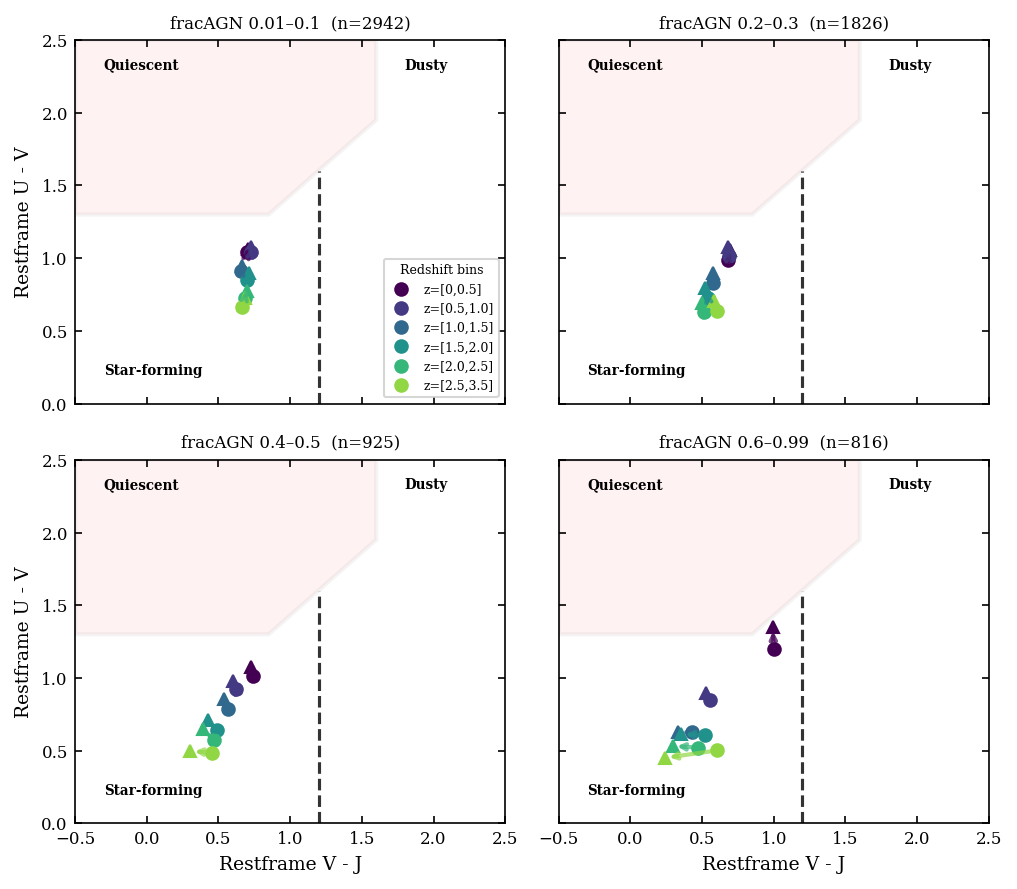

In [6]:
# Fig C: Redshift divergence within each fracAGN bin (2x2 grid, Fig 8 style per panel)
z_bins = [[0, 0.5], [0.5, 1.0], [1.0, 1.5], [1.5, 2.0], [2.0, 2.5], [2.5, 3.5]]
cmap = plt.cm.viridis

fig, axes = plt.subplots(2, 2, figsize=(6.85, 6.0), sharex=True, sharey=True)
for ax, (lo, hi, label) in zip(axes.flat, FRAC_BINS):
    d = df_cig[(df_cig['fracAGN'] > lo) & (df_cig['fracAGN'] <= hi)]
    visualization.plot_uvj_diagram([], [], ax=ax, title="")
    for i, (z_min, z_max) in enumerate(z_bins):
        sub = d[(d[z_col] >= z_min) & (d[z_col] < z_max)]
        if len(sub) < 5: continue
        mvj_f, muv_f = sub['VJ_Full'].mean(), sub['UV_Full'].mean()
        mvj_d, muv_d = sub['VJ_Decomposed'].mean(), sub['UV_Decomposed'].mean()
        c = cmap(i / len(z_bins))
        ax.plot(mvj_f, muv_f, 'o', color=c, markersize=6, label=f'z=[{z_min},{z_max}]')
        ax.plot(mvj_d, muv_d, '^', color=c, markersize=6)
        ax.annotate('', xy=(mvj_d, muv_d), xytext=(mvj_f, muv_f),
                    arrowprops=dict(arrowstyle="->", color=c, lw=2, alpha=0.7))
    ax.set_title(f'fracAGN {label}  (n={len(d)})', fontsize=8)
    for txt in ax.texts:
        txt.set_fontsize(6.5)

axes.flat[0].legend(loc='lower right', title="Redshift bins", title_fontsize=6, fontsize=6)
for ax in axes[0, :]: ax.set_xlabel('')
for ax in axes[:, 1]: ax.set_ylabel('')
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_redshift_fracAGN_bins.pdf'), dpi=300, bbox_inches='tight')
plt.show()

       Cut         Region      dVJ      dUV  |shift|      n
      >0.0      Quiescent   +0.001   +0.041    0.041    496
      >0.0   Star-forming   -0.035   +0.036    0.050   5551
      >0.0          Dusty   -0.016   +0.125    0.126    462
      >0.1      Quiescent   -0.001   +0.055    0.055    201
      >0.1   Star-forming   -0.064   +0.043    0.077   3214
      >0.1          Dusty   -0.115   +0.150    0.189    152
      >0.2      Quiescent   -0.007   +0.036    0.037     97
      >0.2   Star-forming   -0.088   +0.038    0.096   2270
      >0.2          Dusty   -0.250   +0.064    0.258     90
      >0.5      Quiescent   -0.004   +0.002    0.004     12
      >0.5   Star-forming   -0.170   +0.005    0.170    773
      >0.5          Dusty   -0.768   -0.142    0.781     31


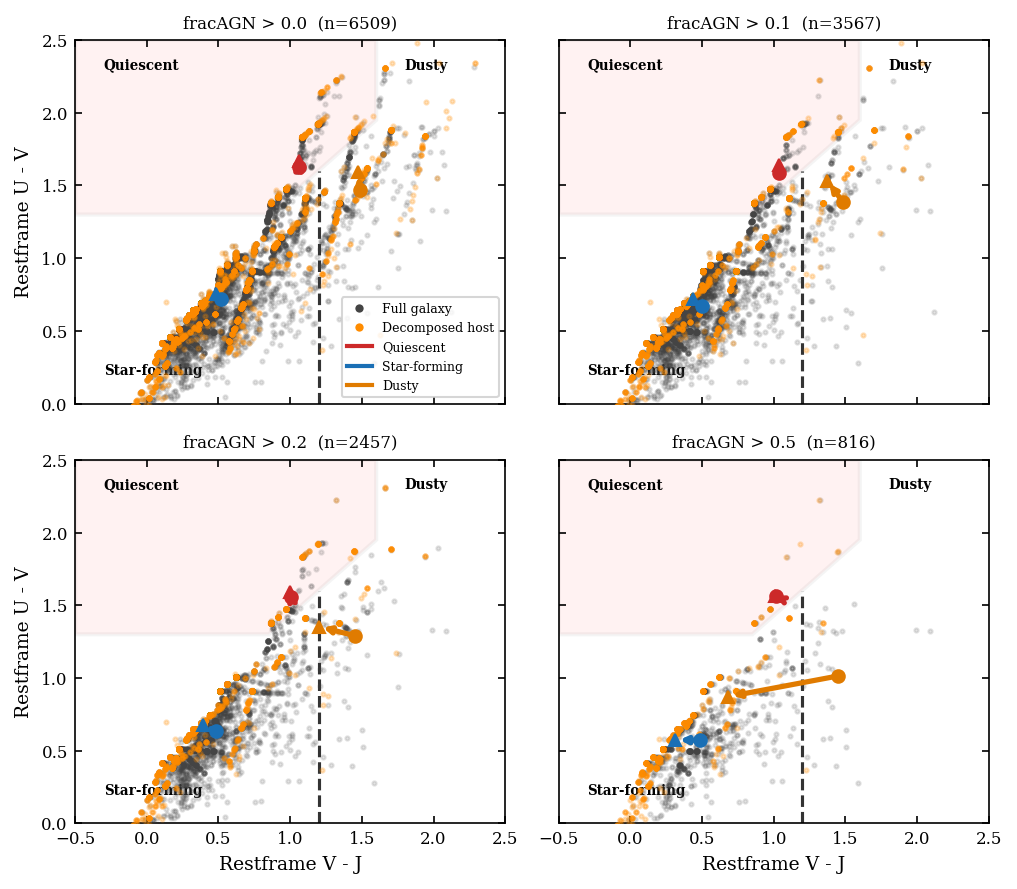

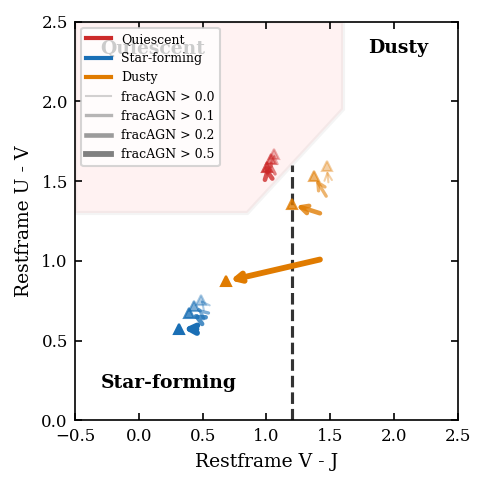

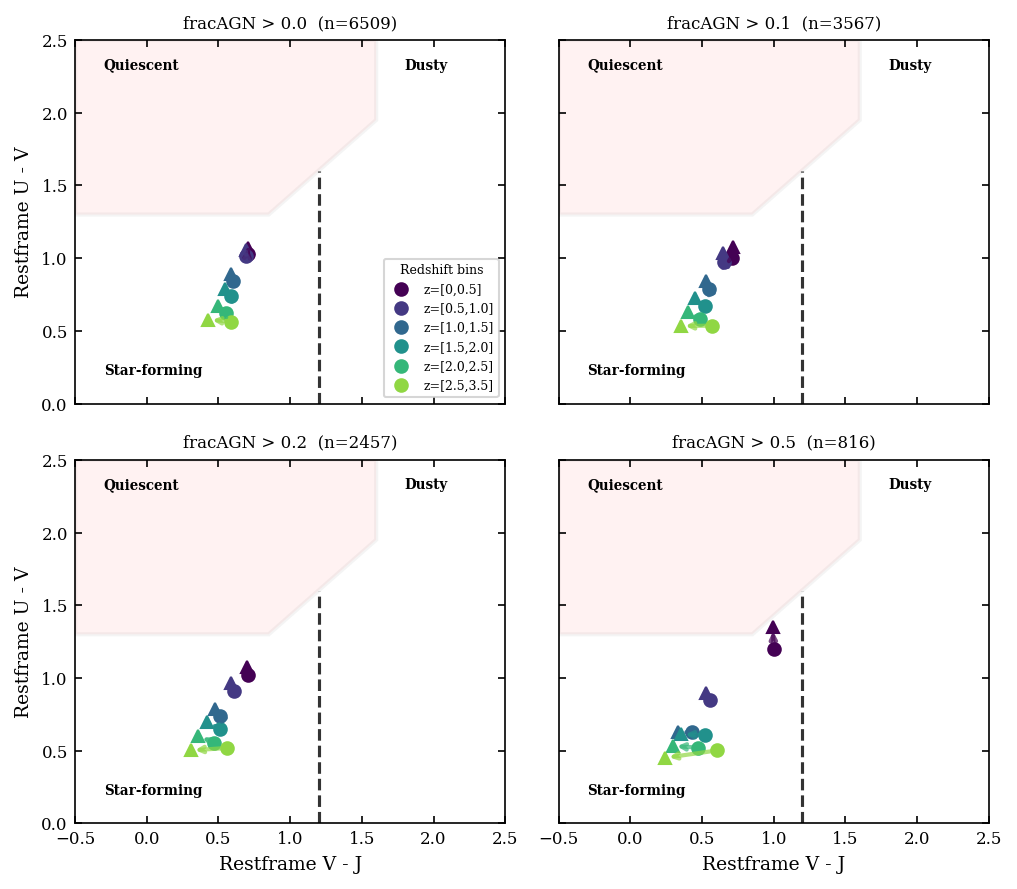

In [7]:
# Cumulative fracAGN cutoffs: what the paper figure looks like at each candidate cut.
# Panels overlap in membership (every galaxy in >0.5 is also in >0), unlike the
# disjoint bins above — use these to choose AGN_FRAC_MIN for the paper figures.
FRAC_CUTS = [0.0, 0.1, 0.2, 0.5]

# Fig D: 2x2 UVJ grid — scatter + per-region mean shift arrows for each cutoff
fig, axes = plt.subplots(2, 2, figsize=(6.85, 6.0), sharex=True, sharey=True)
print(f"{'Cut':>10} {'Region':>14} {'dVJ':>8} {'dUV':>8} {'|shift|':>8} {'n':>6}")
for ax, cut in zip(axes.flat, FRAC_CUTS):
    d = df_cig[df_cig['fracAGN'] > cut]
    visualization.plot_uvj_diagram([], [], ax=ax, title="")
    ax.scatter(d['VJ_Full'],       d['UV_Full'],       c='#444444',    s=4, alpha=0.15, zorder=3)
    ax.scatter(d['VJ_Decomposed'], d['UV_Decomposed'], c='darkorange', s=4, alpha=0.25, zorder=3)
    for cid, (vj_f, uv_f, vj_d, uv_d, n) in region_mean_shifts(d).items():
        print(f"{'>' + str(cut):>10} {region_names[cid]:>14} {vj_d - vj_f:>+8.3f} {uv_d - uv_f:>+8.3f} "
              f"{np.hypot(vj_d - vj_f, uv_d - uv_f):>8.3f} {n:>6}")
        ax.annotate('', xy=(vj_d, uv_d), xytext=(vj_f, uv_f),
                    arrowprops=dict(arrowstyle='->', color=region_colors[cid], lw=2.5))
        ax.plot(vj_f, uv_f, 'o', color=region_colors[cid], markersize=6, zorder=6)
        ax.plot(vj_d, uv_d, '^', color=region_colors[cid], markersize=6, zorder=6)
    ax.set_title(f'fracAGN > {cut}  (n={len(d)})', fontsize=8)
    for txt in ax.texts:
        txt.set_fontsize(6.5)

legend_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor='#444444', markersize=5, label='Full galaxy'),
                  Line2D([0], [0], marker='o', color='w', markerfacecolor='darkorange', markersize=5, label='Decomposed host')] + \
                 [Line2D([0], [0], color=region_colors[cid], lw=2, label=region_names[cid]) for cid in [0, 1, 2]]
axes.flat[0].legend(handles=legend_handles, loc='lower right', fontsize=6)
for ax in axes[0, :]: ax.set_xlabel('')
for ax in axes[:, 1]: ax.set_ylabel('')
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_FullDecomp_Vectors_fracAGN_cuts.pdf'), dpi=300, bbox_inches='tight')
plt.show()

# Fig E: single-axis summary — per-region mean shift arrows for all cutoffs
fig, ax = plt.subplots(figsize=visualization.PASA_SQ)
visualization.plot_uvj_diagram([], [], ax=ax, title="")
cut_alphas = np.linspace(0.35, 1.0, len(FRAC_CUTS))
cut_lws    = np.linspace(1.0, 2.8, len(FRAC_CUTS))
for i, cut in enumerate(FRAC_CUTS):
    d = df_cig[df_cig['fracAGN'] > cut]
    for cid, (vj_f, uv_f, vj_d, uv_d, n) in region_mean_shifts(d, min_n=20).items():
        ax.annotate('', xy=(vj_d, uv_d), xytext=(vj_f, uv_f),
                    arrowprops=dict(arrowstyle='->', color=region_colors[cid],
                                    lw=cut_lws[i], alpha=cut_alphas[i]))
        ax.plot(vj_d, uv_d, '^', color=region_colors[cid], markersize=5,
                alpha=cut_alphas[i], zorder=6)
legend_handles = [Line2D([0], [0], color=region_colors[cid], lw=2, label=region_names[cid]) for cid in [0, 1, 2]] + \
                 [Line2D([0], [0], color='gray', lw=cut_lws[i], alpha=cut_alphas[i], label=f'fracAGN > {c}')
                  for i, c in enumerate(FRAC_CUTS)]
ax.legend(handles=legend_handles, loc='upper left', fontsize=6)
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_FullDecomp_Vectors_fracAGN_cuts_summary.pdf'), dpi=300, bbox_inches='tight')
plt.show()

# Fig F: redshift divergence at each cutoff (2x2 grid, Fig 8 style per panel)
fig, axes = plt.subplots(2, 2, figsize=(6.85, 6.0), sharex=True, sharey=True)
for ax, cut in zip(axes.flat, FRAC_CUTS):
    d = df_cig[df_cig['fracAGN'] > cut]
    visualization.plot_uvj_diagram([], [], ax=ax, title="")
    for i, (z_min, z_max) in enumerate(z_bins):
        sub = d[(d[z_col] >= z_min) & (d[z_col] < z_max)]
        if len(sub) < 5: continue
        mvj_f, muv_f = sub['VJ_Full'].mean(), sub['UV_Full'].mean()
        mvj_d, muv_d = sub['VJ_Decomposed'].mean(), sub['UV_Decomposed'].mean()
        c = cmap(i / len(z_bins))
        ax.plot(mvj_f, muv_f, 'o', color=c, markersize=6, label=f'z=[{z_min},{z_max}]')
        ax.plot(mvj_d, muv_d, '^', color=c, markersize=6)
        ax.annotate('', xy=(mvj_d, muv_d), xytext=(mvj_f, muv_f),
                    arrowprops=dict(arrowstyle="->", color=c, lw=2, alpha=0.7))
    ax.set_title(f'fracAGN > {cut}  (n={len(d)})', fontsize=8)
    for txt in ax.texts:
        txt.set_fontsize(6.5)

axes.flat[0].legend(loc='lower right', title="Redshift bins", title_fontsize=6, fontsize=6)
for ax in axes[0, :]: ax.set_xlabel('')
for ax in axes[:, 1]: ax.set_ylabel('')
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_redshift_fracAGN_cuts.pdf'), dpi=300, bbox_inches='tight')
plt.show()

### 9c. Hidden quiescent galaxies revealed by decomposition

Population means dilute the decomposition effect because only a few per cent of AGN hosts change UVJ class. Tracking **per-galaxy classification transitions** (full → decomposed) exposes the systematic migration directly: AGN light disguises quiescent hosts as star-forming/dusty, and removing it moves them back — never the reverse.

Transition matrix (rows = full, cols = decomposed):
cls_dec     D    Q    SF
cls_full                
D         357   78    27
Q           0  496     0
SF         26  215  5310


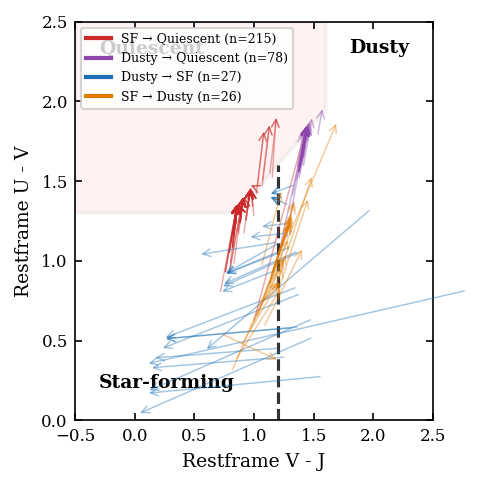

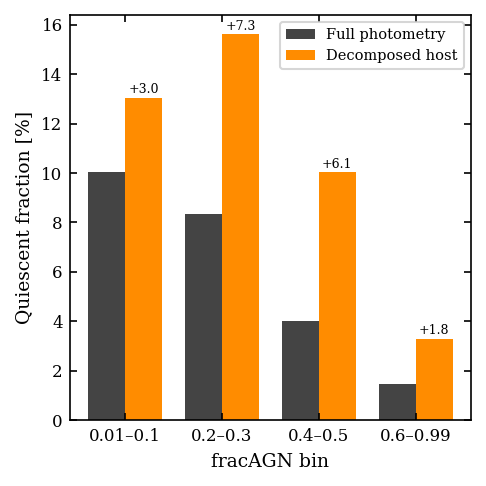

In [8]:
# Per-galaxy UVJ class transitions between full and decomposed photometry.
# Population means hide the effect: only ~5% of AGN hosts change class, but the
# migration is one-directional (SF/D -> Q; zero Q -> SF), i.e. AGN light disguises
# quiescent hosts as star-forming — the systematic shift predicted by the methodology.
d = df_cig[df_cig['fracAGN'] > 0].copy()
d['cls_full'] = photometry.classify_uvj(d['VJ_Full'].values, d['UV_Full'].values)
d['cls_dec']  = photometry.classify_uvj(d['VJ_Decomposed'].values, d['UV_Decomposed'].values)

cls_names = {0: 'Q', 1: 'SF', 2: 'D'}
print('Transition matrix (rows = full, cols = decomposed):')
print(pd.crosstab(d['cls_full'].map(cls_names), d['cls_dec'].map(cls_names)))

# Fig G: migration arrows for class-changing galaxies only
transition_styles = {
    (1, 0): ('#CC2929', 'SF → Quiescent'),
    (2, 0): ('#8E44AD', 'Dusty → Quiescent'),
    (2, 1): ('#1A6FB5', 'Dusty → SF'),
    (1, 2): ('#E07B00', 'SF → Dusty'),
}
fig, ax = plt.subplots(figsize=visualization.PASA_SQ)
visualization.plot_uvj_diagram([], [], ax=ax, title="")
for (c_from, c_to), (color, label) in transition_styles.items():
    m = (d['cls_full'] == c_from) & (d['cls_dec'] == c_to)
    for _, row in d[m].iterrows():
        ax.annotate('', xy=(row['VJ_Decomposed'], row['UV_Decomposed']),
                    xytext=(row['VJ_Full'], row['UV_Full']),
                    arrowprops=dict(arrowstyle='->', color=color, lw=0.7, alpha=0.4))
legend_handles = [Line2D([0], [0], color=c, lw=2,
                         label=f'{lab} (n={((d["cls_full"] == f) & (d["cls_dec"] == t)).sum()})')
                  for (f, t), (c, lab) in transition_styles.items()]
ax.legend(handles=legend_handles, loc='upper left', fontsize=6)
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_class_migrations.pdf'), dpi=300, bbox_inches='tight')
plt.show()

# Fig H: quiescent fraction before/after decomposition per fracAGN bin
q_full, q_dec, labels = [], [], []
for lo, hi, label in FRAC_BINS:
    b = d[(d['fracAGN'] > lo) & (d['fracAGN'] <= hi)]
    q_full.append(100 * (b['cls_full'] == 0).mean())
    q_dec.append(100 * (b['cls_dec'] == 0).mean())
    labels.append(label)

fig, ax = plt.subplots(figsize=visualization.PASA_SQ)
x = np.arange(len(labels))
w = 0.38
ax.bar(x - w/2, q_full, w, color='#444444',    label='Full photometry')
ax.bar(x + w/2, q_dec,  w, color='darkorange', label='Decomposed host')
for xi, (qf, qd) in enumerate(zip(q_full, q_dec)):
    ax.annotate(f'+{qd - qf:.1f}', (xi + w/2, qd), textcoords='offset points',
                xytext=(0, 2), ha='center', fontsize=6)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel('fracAGN bin')
ax.set_ylabel('Quiescent fraction [%]')
ax.legend(fontsize=7)
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_hidden_quiescent_fraction.pdf'), dpi=300, bbox_inches='tight')
plt.show()

### 9d. Deeper dives into the hidden-quiescent effect

Four follow-up angles on the class-transition result of 9c (all read variables from earlier cells — run sections 2, 9, 9b and 9c first):
1. **Hidden quiescent fraction vs redshift** — when does AGN light hide the most quiescence?
2. **Theory tie-back** — observed migration arrows vs the Type 1 composite evolution tracks (decomposition should be antiparallel to increasing $\alpha$).
3. **Distance to the quiescent wedge** — the sub-threshold population moving toward the wedge without crossing.
4. **Mover properties** — fracAGN, redshift and stellar-mass distributions of reclassified galaxies.

z bin | n | Q_full% | Q_dec% | hidden pp
[0,0.5) |   463 |  19.0 |  21.8 | +2.8
[0.5,1.0) |  2198 |  17.3 |  26.6 | +9.3
[1.0,1.5) |  1145 |   2.4 |   9.0 | +6.6
[1.5,2.0) |  1296 |   0.0 |   0.0 | +0.0
[2.0,2.5) |   891 |   0.0 |   0.0 | +0.0
[2.5,3.5) |   510 |   0.0 |   0.0 | +0.0


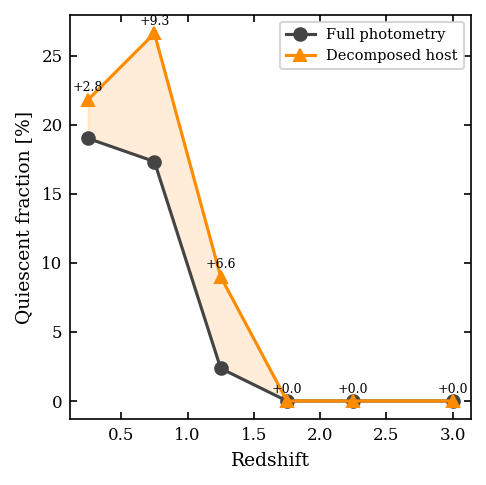

In [9]:
# Angle 1 — hidden quiescent fraction vs redshift: when in cosmic time does AGN
# light hide the most quiescent galaxies?
q_full_z, q_dec_z, z_mids, z_ns = [], [], [], []
for z_min, z_max in z_bins:
    b = d[(d[z_col] >= z_min) & (d[z_col] < z_max)]
    if len(b) < 20: continue
    q_full_z.append(100 * (b['cls_full'] == 0).mean())
    q_dec_z.append(100 * (b['cls_dec'] == 0).mean())
    z_mids.append(0.5 * (z_min + z_max))
    z_ns.append(len(b))

fig, ax = plt.subplots(figsize=visualization.PASA_SQ)
ax.plot(z_mids, q_full_z, 'o-', color='#444444',    label='Full photometry')
ax.plot(z_mids, q_dec_z,  '^-', color='darkorange', label='Decomposed host')
ax.fill_between(z_mids, q_full_z, q_dec_z, color='darkorange', alpha=0.15)
for zm, qf, qd, n in zip(z_mids, q_full_z, q_dec_z, z_ns):
    ax.annotate(f'+{qd - qf:.1f}', (zm, qd), textcoords='offset points',
                xytext=(0, 4), ha='center', fontsize=6)
ax.set_xlabel('Redshift')
ax.set_ylabel('Quiescent fraction [%]')
ax.legend(fontsize=7)
print('z bin | n | Q_full% | Q_dec% | hidden pp')
for (z_min, z_max), qf, qd, n in zip(z_bins, q_full_z, q_dec_z, z_ns):
    print(f'[{z_min},{z_max}) | {n:5d} | {qf:5.1f} | {qd:5.1f} | {qd - qf:+.1f}')
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_hidden_quiescent_redshift.pdf'), dpi=300, bbox_inches='tight')
plt.show()

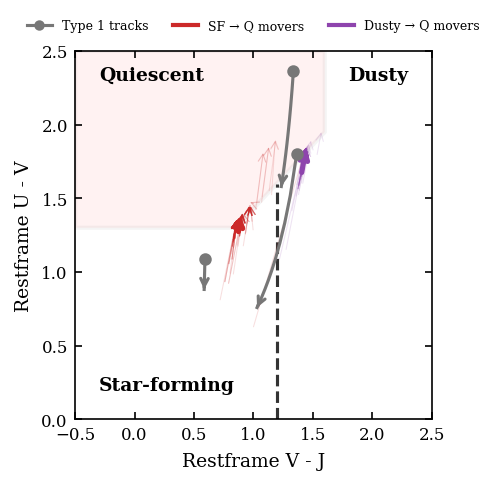

In [10]:
# Angle 2 — tie-back to theory: observed decomposition arrows vs Type 1 composite
# evolution tracks (section 2). Decomposition removes AGN light, so observed arrows
# should run ANTIPARALLEL to the increasing-alpha model tracks.
# Requires df_results from section 2; skipped otherwise.
if 'df_results' in dir():
    rep_templates = {'NGC_0337': 'Star-forming host', 'NGC_4552': 'Quiescent host', 'IC_4553': 'Dusty host'}
    fig, ax = plt.subplots(figsize=visualization.PASA_SQ)
    visualization.plot_uvj_diagram([], [], ax=ax, title="")

    # Model tracks: alpha = 0 -> 1, arrowhead at high-alpha end
    for tname, tlabel in rep_templates.items():
        t = df_results[(df_results['AGN_Type'] == 'Type1') & (df_results['Template'] == tname)].sort_values('Alpha')
        ax.plot(t['V-J'], t['U-V'], '-', color='#777777', lw=1.5, zorder=4)
        ax.annotate('', xy=(t['V-J'].iloc[-1], t['U-V'].iloc[-1]),
                    xytext=(t['V-J'].iloc[-2], t['U-V'].iloc[-2]),
                    arrowprops=dict(arrowstyle='->', color='#777777', lw=1.5))
        ax.plot(t['V-J'].iloc[0], t['U-V'].iloc[0], 'o', color='#777777', markersize=5, zorder=5)

    # Observed migrations to quiescent (individual, faint) + bold mean arrows
    for (c_from, color, lab) in [(1, '#CC2929', 'SF → Q movers'), (2, '#8E44AD', 'Dusty → Q movers')]:
        m = d[(d['cls_full'] == c_from) & (d['cls_dec'] == 0)]
        if len(m) == 0: continue
        for _, row in m.iterrows():
            ax.annotate('', xy=(row['VJ_Decomposed'], row['UV_Decomposed']),
                        xytext=(row['VJ_Full'], row['UV_Full']),
                        arrowprops=dict(arrowstyle='->', color=color, lw=0.5, alpha=0.15))
        ax.annotate('', xy=(m['VJ_Decomposed'].mean(), m['UV_Decomposed'].mean()),
                    xytext=(m['VJ_Full'].mean(), m['UV_Full'].mean()),
                    arrowprops=dict(arrowstyle='->', color=color, lw=2.5))

    legend_handles = [
        Line2D([0], [0], color='#777777', lw=1.5, marker='o', markersize=4,
               label='Type 1 tracks'),
        Line2D([0], [0], color='#CC2929', lw=2, label='SF → Q movers'),
        Line2D([0], [0], color='#8E44AD', lw=2, label='Dusty → Q movers'),
    ]
    ax.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=3, fontsize=6, frameon=False)
    plt.tight_layout()
    fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_migrations_vs_theory.pdf'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("df_results not in memory — run section 2 first for the theory overlay.")

Non-quiescent (full) AGN hosts: 6013
  moved TOWARD the quiescent wedge: 3487 (58.0%)
  moved away: 916 (15.2%)
  within 0.05 mag of wedge (incl. inside): full=147, decomposed=296 (+149)
  within 0.1 mag of wedge (incl. inside): full=279, decomposed=484 (+205)
  within 0.2 mag of wedge (incl. inside): full=554, decomposed=707 (+153)


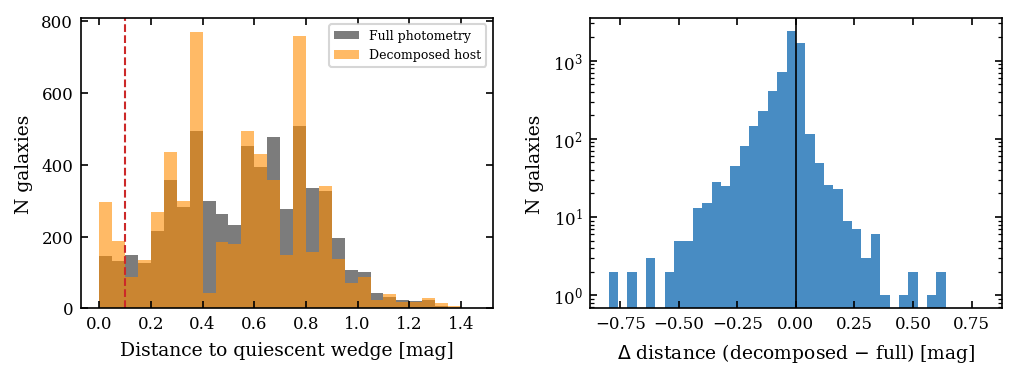

In [11]:
# Angle 3 — distance to the quiescent wedge before/after decomposition.
# Many hosts move TOWARD the wedge without crossing it; counting galaxies near the
# boundary captures this sub-threshold population beyond the 293 outright movers.
Q_BOUNDARY_SEGS = [((-0.5, 1.3), (0.85, 1.3)), ((0.85, 1.3), (1.6, 1.95)), ((1.6, 1.95), (1.6, 2.5))]

def dist_to_quiescent(vj, uv, cls):
    """Distance in colour space to the quiescent wedge boundary (0 if inside)."""
    vj, uv = np.asarray(vj, float), np.asarray(uv, float)
    dists = []
    for (x1, y1), (x2, y2) in Q_BOUNDARY_SEGS:
        dx, dy = x2 - x1, y2 - y1
        t = np.clip(((vj - x1) * dx + (uv - y1) * dy) / (dx**2 + dy**2), 0, 1)
        dists.append(np.hypot(vj - (x1 + t * dx), uv - (y1 + t * dy)))
    dist = np.min(dists, axis=0)
    dist[np.asarray(cls) == 0] = 0.0
    return dist

nonq = d[d['cls_full'] != 0].copy()
nonq['dist_full'] = dist_to_quiescent(nonq['VJ_Full'], nonq['UV_Full'], nonq['cls_full'])
nonq['dist_dec']  = dist_to_quiescent(nonq['VJ_Decomposed'], nonq['UV_Decomposed'], nonq['cls_dec'])
delta = nonq['dist_dec'] - nonq['dist_full']

closer = (delta < -1e-3).sum()
farther = (delta > 1e-3).sum()
print(f"Non-quiescent (full) AGN hosts: {len(nonq)}")
print(f"  moved TOWARD the quiescent wedge: {closer} ({100*closer/len(nonq):.1f}%)")
print(f"  moved away: {farther} ({100*farther/len(nonq):.1f}%)")
for r in [0.05, 0.1, 0.2]:
    nf = (nonq['dist_full'] <= r).sum()
    nd = (nonq['dist_dec'] <= r).sum()
    print(f"  within {r} mag of wedge (incl. inside): full={nf}, decomposed={nd} ({nd-nf:+d})")

fig, axes = plt.subplots(1, 2, figsize=(6.85, 2.6))
db = np.arange(0, 1.5, 0.05)
axes[0].hist(nonq['dist_full'], bins=db, color='#444444',    alpha=0.7, label='Full photometry')
axes[0].hist(nonq['dist_dec'],  bins=db, color='darkorange', alpha=0.6, label='Decomposed host')
axes[0].axvline(0.1, color='#CC2929', ls='--', lw=1)
axes[0].set_xlabel('Distance to quiescent wedge [mag]')
axes[0].set_ylabel('N galaxies')
axes[0].legend(fontsize=6)

dbins = np.arange(-0.8, 0.81, 0.04)
axes[1].hist(delta.clip(-0.8, 0.8), bins=dbins, color='#1A6FB5', alpha=0.8)
axes[1].axvline(0, color='k', lw=0.8)
axes[1].set_xlabel(r'$\Delta$ distance (decomposed $-$ full) [mag]')
axes[1].set_ylabel('N galaxies')
axes[1].set_yscale('log')
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_boundary_distance.pdf'), dpi=300, bbox_inches='tight')
plt.show()

Movers to quiescent: 293 of 6509 AGN hosts
Movers:  median z = 0.90, median lmass = 9.38, median fracAGN = 0.20
Others:  median z = 1.30, median lmass = 9.07, median fracAGN = 0.20


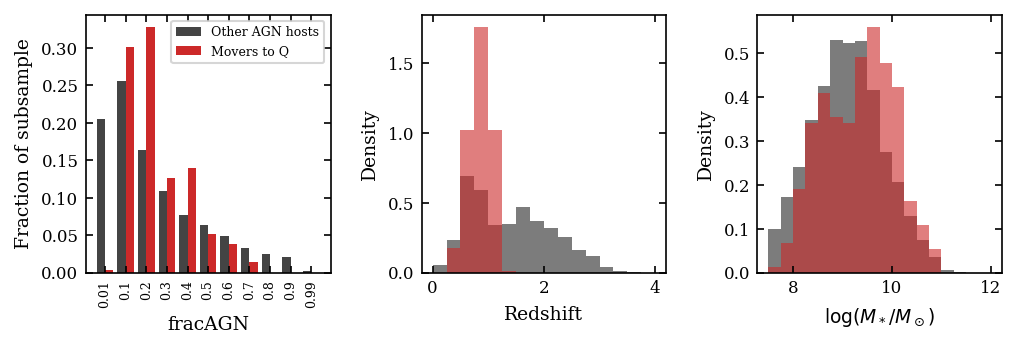

In [12]:
# Angle 4 — who are the movers? fracAGN, redshift and stellar mass distributions of
# galaxies reclassified as quiescent (SF->Q or D->Q), compared against all AGN hosts.
movers = d[(d['cls_dec'] == 0) & (d['cls_full'] != 0)]
others = d[~((d['cls_dec'] == 0) & (d['cls_full'] != 0))]
print(f"Movers to quiescent: {len(movers)} of {len(d)} AGN hosts")

fig, axes = plt.subplots(1, 3, figsize=(6.85, 2.4))

# fracAGN is discrete -> normalised bar chart per value
frac_vals = sorted(d['fracAGN'].unique())
x = np.arange(len(frac_vals))
w = 0.4
mv = movers['fracAGN'].value_counts(normalize=True).reindex(frac_vals, fill_value=0)
ot = others['fracAGN'].value_counts(normalize=True).reindex(frac_vals, fill_value=0)
axes[0].bar(x - w/2, ot.values, w, color='#444444',    label='Other AGN hosts')
axes[0].bar(x + w/2, mv.values, w, color='#CC2929',    label='Movers to Q')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'{v:g}' for v in frac_vals], rotation=90, fontsize=6)
axes[0].set_xlabel('fracAGN')
axes[0].set_ylabel('Fraction of subsample')

zbins_h = np.arange(0, 4.01, 0.25)
axes[1].hist(others[z_col], bins=zbins_h, density=True, color='#444444', alpha=0.7)
axes[1].hist(movers[z_col], bins=zbins_h, density=True, color='#CC2929', alpha=0.6)
axes[1].set_xlabel('Redshift')
axes[1].set_ylabel('Density')

mgood_m = movers['lmass'] > 0
mgood_o = others['lmass'] > 0
mbins = np.arange(7.5, 12.01, 0.25)
axes[2].hist(others.loc[mgood_o, 'lmass'], bins=mbins, density=True, color='#444444', alpha=0.7)
axes[2].hist(movers.loc[mgood_m, 'lmass'], bins=mbins, density=True, color='#CC2929', alpha=0.6)
axes[2].set_xlabel(r'$\log(M_*/M_\odot)$')
axes[2].set_ylabel('Density')

axes[0].legend(fontsize=6)
print(f"Movers:  median z = {movers[z_col].median():.2f}, median lmass = {movers.loc[mgood_m,'lmass'].median():.2f}, median fracAGN = {movers['fracAGN'].median():.2f}")
print(f"Others:  median z = {others[z_col].median():.2f}, median lmass = {others.loc[mgood_o,'lmass'].median():.2f}, median fracAGN = {others['fracAGN'].median():.2f}")
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_mover_properties.pdf'), dpi=300, bbox_inches='tight')
plt.show()

### 9e. Hidden-quiescent maps in UVJ space

The bar/line charts above give the numbers; these panels show **where in colour space the fraction change happens**. Each UVJ panel contains the full AGN-host population of the bin (faint grey, full-photometry positions), red arrows tracking each recovered quiescent galaxy from its full position into the wedge, and the quiescent fraction before → after decomposition annotated in-panel. One grid across redshift (the z > 1.5 panel is the null test — no arrows, no fraction change) and one across fracAGN bins.

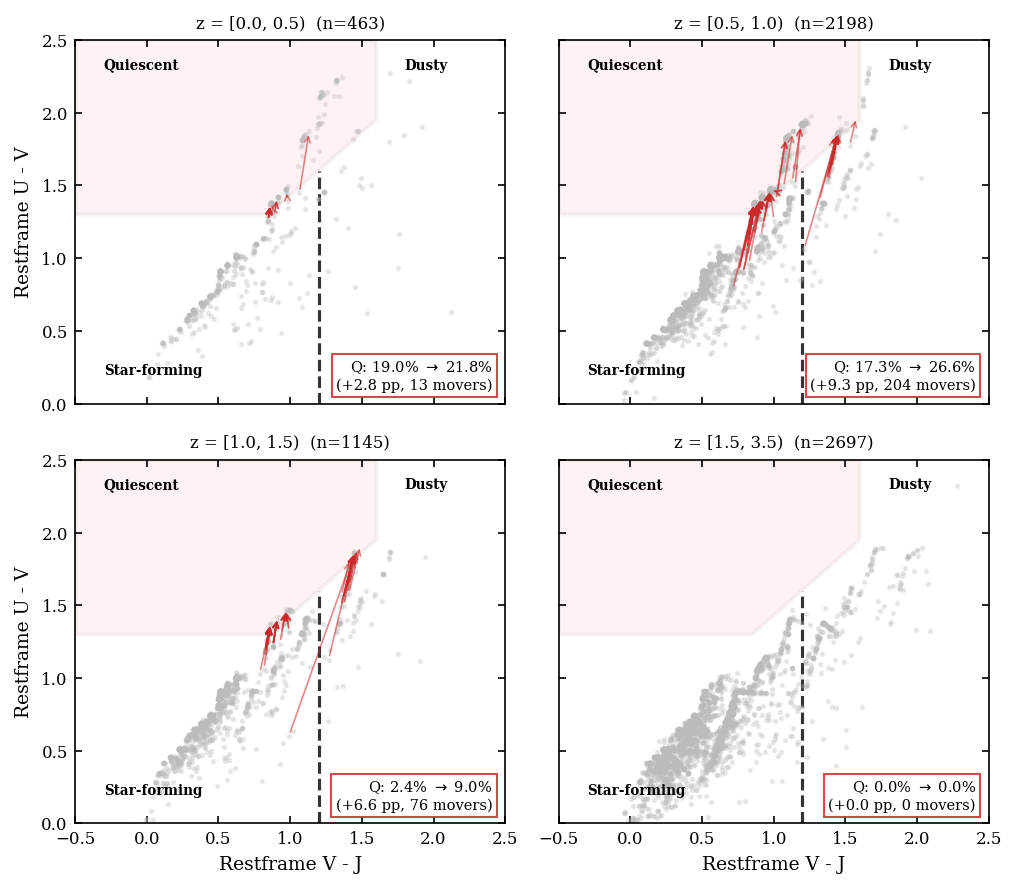

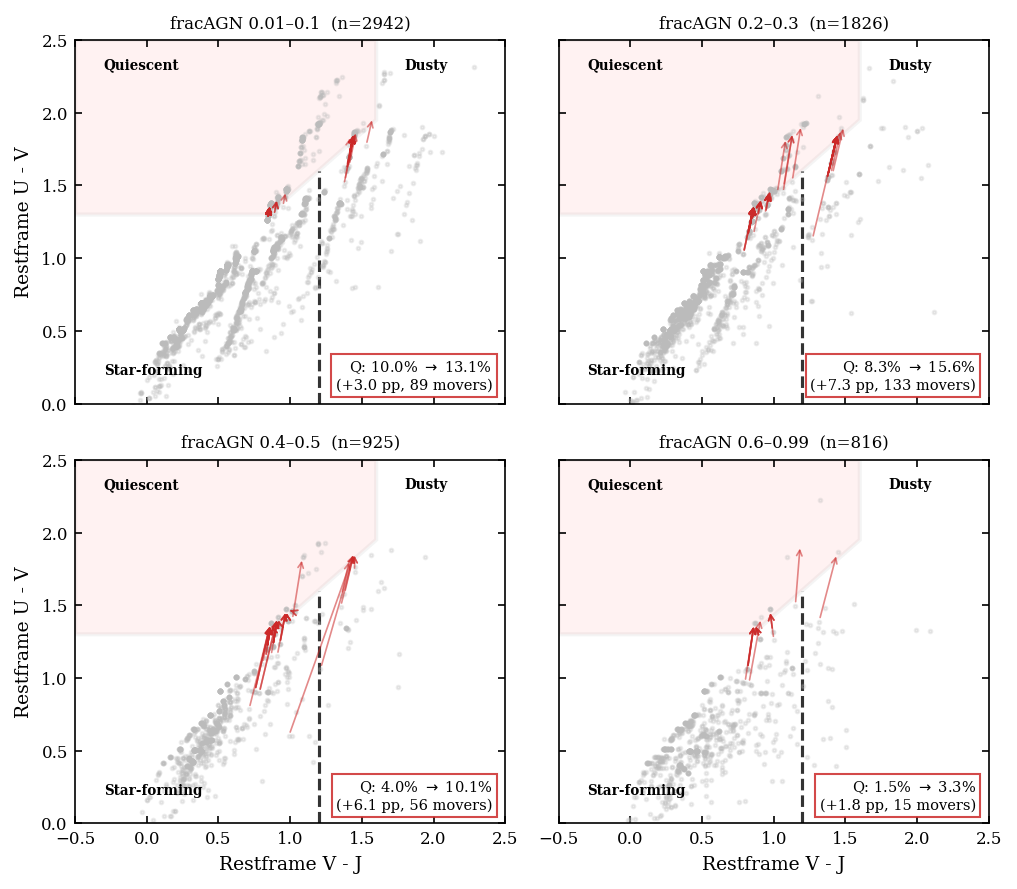

In [13]:
# Hidden-quiescent maps: UVJ panels showing WHERE the fraction change comes from.
# Each panel: all AGN hosts in the bin (faint grey, full positions), red arrows for
# the movers into the quiescent wedge, and the Q fraction before -> after annotated.
def hidden_quiescent_map(ax, sub, title, show_stats=True, mean_arrows=False, min_n_mean=15):
    """
    UVJ panel: all AGN hosts in the bin (faint grey, full positions), plus
    either per-galaxy red arrows for each mover into quiescent (default,
    matches the original paper figures), or a single mean-shift arrow per
    UVJ region if mean_arrows=True. show_stats controls the in-panel
    Q% -> Q% annotation box (off by default for the draft variants below,
    since that's now captured in the dedicated trend/table figures instead).
    """
    visualization.plot_uvj_diagram([], [], ax=ax, title="")
    ax.scatter(sub['VJ_Full'], sub['UV_Full'], c='#BBBBBB', s=3, alpha=0.25, zorder=2)
    movers = sub[(sub['cls_full'] != 0) & (sub['cls_dec'] == 0)]
    if mean_arrows:
        for cid, (vj_f, uv_f, vj_d, uv_d, n) in region_mean_shifts(sub, min_n=min_n_mean).items():
            ax.annotate('', xy=(vj_d, uv_d), xytext=(vj_f, uv_f),
                        arrowprops=dict(arrowstyle='->', color=region_colors[cid], lw=2.5))
            ax.plot(vj_f, uv_f, 'o', color=region_colors[cid], markersize=6, zorder=6)
            ax.plot(vj_d, uv_d, '^', color=region_colors[cid], markersize=6, zorder=6)
    else:
        for _, row in movers.iterrows():
            ax.annotate('', xy=(row['VJ_Decomposed'], row['UV_Decomposed']),
                        xytext=(row['VJ_Full'], row['UV_Full']),
                        arrowprops=dict(arrowstyle='->', color='#CC2929', lw=0.8, alpha=0.55))
    if show_stats:
        qf = 100 * (sub['cls_full'] == 0).mean()
        qd = 100 * (sub['cls_dec'] == 0).mean()
        ax.text(0.97, 0.03, f'Q: {qf:.1f}% $\\rightarrow$ {qd:.1f}%\n({qd - qf:+.1f} pp, {len(movers)} movers)',
                transform=ax.transAxes, ha='right', va='bottom', fontsize=7,
                bbox=dict(facecolor='white', edgecolor='#CC2929', alpha=0.85, pad=2))
    ax.set_title(title, fontsize=8)
    for txt in ax.texts[:-1] if show_stats else ax.texts:
        txt.set_fontsize(6.5)

# Map 1: across redshift (last panel combines z > 1.5 where the effect vanishes — the null test)
map_z_bins = [(0.0, 0.5), (0.5, 1.0), (1.0, 1.5), (1.5, 3.5)]
fig, axes = plt.subplots(2, 2, figsize=(6.85, 6.0), sharex=True, sharey=True)
for ax, (z_min, z_max) in zip(axes.flat, map_z_bins):
    sub = d[(d[z_col] >= z_min) & (d[z_col] < z_max)]
    hidden_quiescent_map(ax, sub, f'z = [{z_min}, {z_max})  (n={len(sub)})')
for ax in axes[0, :]: ax.set_xlabel('')
for ax in axes[:, 1]: ax.set_ylabel('')
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_hidden_quiescent_maps_redshift.pdf'), dpi=300, bbox_inches='tight')
plt.show()

# Map 2: across disjoint fracAGN bins
fig, axes = plt.subplots(2, 2, figsize=(6.85, 6.0), sharex=True, sharey=True)
for ax, (lo, hi, label) in zip(axes.flat, FRAC_BINS):
    sub = d[(d['fracAGN'] > lo) & (d['fracAGN'] <= hi)]
    hidden_quiescent_map(ax, sub, f'fracAGN {label}  (n={len(sub)})')
for ax in axes[0, :]: ax.set_xlabel('')
for ax in axes[:, 1]: ax.set_ylabel('')
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_hidden_quiescent_maps_fracAGN.pdf'), dpi=300, bbox_inches='tight')
plt.show()

### 9e-v. Exploring map variants (draft -- not yet in the paper)

The maps above use 4 disjoint fracAGN bins chosen for even sample size, which mixes together grid values with very different migration rates (e.g. the 0.6-0.99 bin averages a 3.6% rate at 0.6 down to 0% at 0.99). Trying a few alternatives instead, now that the migration-rate trend (9e-iii) tells us where the effect actually peaks and dies: (1) the same per-galaxy-arrow style but with individual fracAGN values chosen to contrast baseline / rising / peak / gone, (2) the same showcase bins but with a single mean-shift arrow per region instead of one arrow per galaxy, and (3) most of the fracAGN grid at once, to see the whole rise-and-fall directly in UVJ space rather than in the summary trend plot alone. Same treatment applied to the redshift version. All corner Q% stats dropped -- that's covered by the dedicated trend/table figures now.

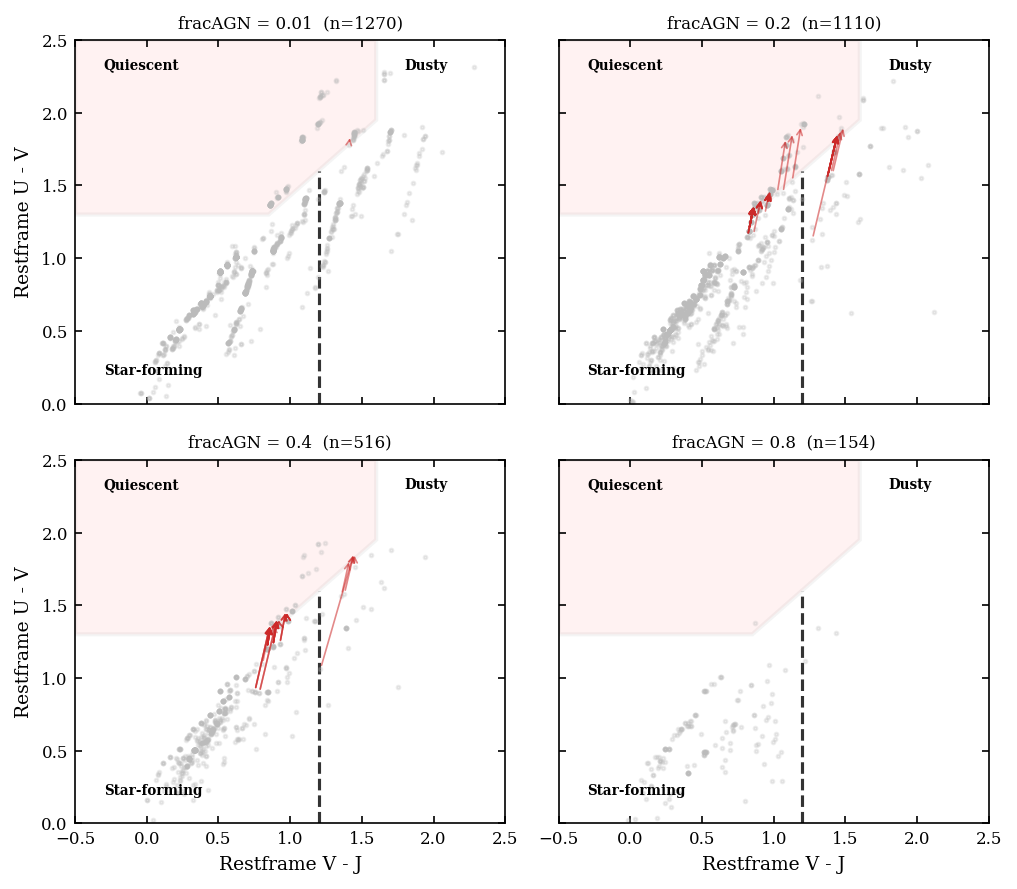

In [14]:
# Showcase fracAGN values chosen from the migration-rate trend (9e-iii):
# 0.01 = baseline (~0% migrate), 0.2 = first/main peak (~9.5%), 0.4 = second
# local peak (~8.4%), 0.8 = effect gone (~0%). Individual-galaxy arrows,
# matching the original map style, no corner stats.
SHOWCASE_FRAC_VALS = [0.01, 0.2, 0.4, 0.8]

fig, axes = plt.subplots(2, 2, figsize=(6.85, 6.0), sharex=True, sharey=True)
for ax, fv in zip(axes.flat, SHOWCASE_FRAC_VALS):
    sub = d[d['fracAGN'] == fv]
    hidden_quiescent_map(ax, sub, f'fracAGN = {fv:g}  (n={len(sub)})', show_stats=False)
for ax in axes[0, :]: ax.set_xlabel('')
for ax in axes[:, 1]: ax.set_ylabel('')
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_migration_showcase_individual.pdf'),
            dpi=300, bbox_inches='tight')
plt.show()

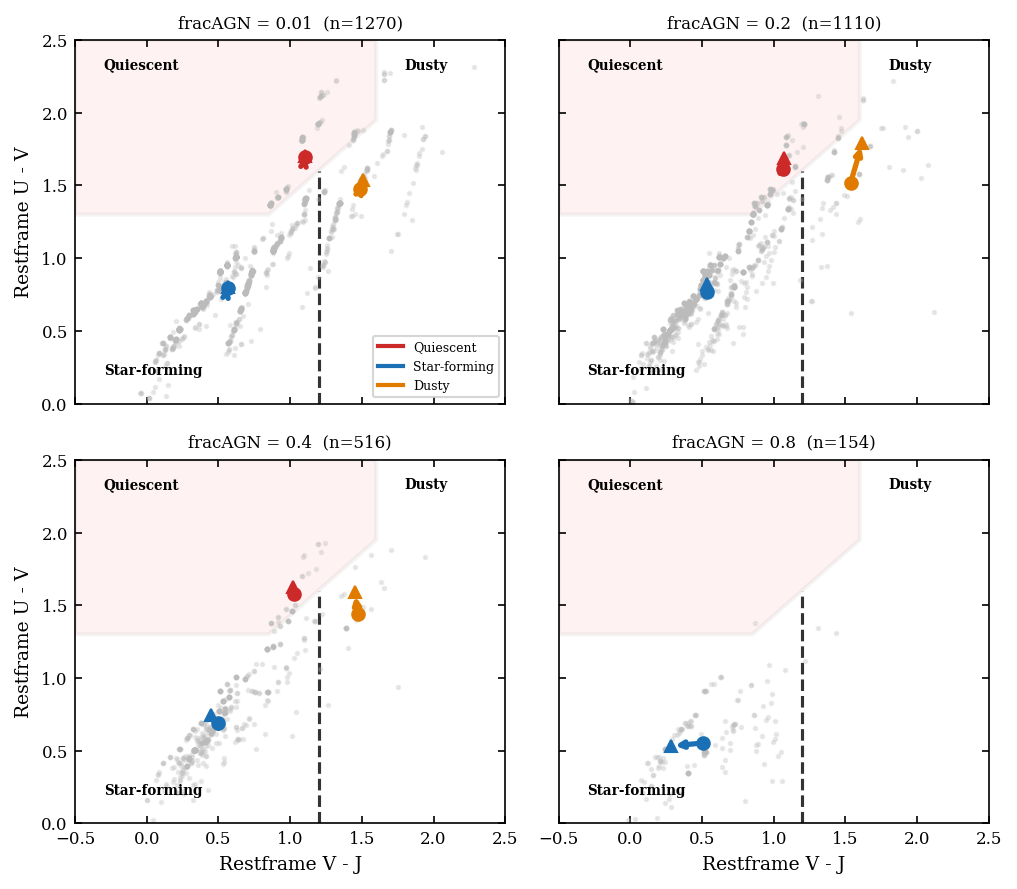

In [15]:
# Same showcase bins, mean-shift arrow per region instead of per-galaxy
# arrows -- less clutter, more directly shows the systematic shift.
fig, axes = plt.subplots(2, 2, figsize=(6.85, 6.0), sharex=True, sharey=True)
for ax, fv in zip(axes.flat, SHOWCASE_FRAC_VALS):
    sub = d[d['fracAGN'] == fv]
    hidden_quiescent_map(ax, sub, f'fracAGN = {fv:g}  (n={len(sub)})',
                          show_stats=False, mean_arrows=True)
legend_handles = [Line2D([0], [0], color=region_colors[cid], lw=2, label=region_names[cid])
                  for cid in [0, 1, 2]]
axes.flat[0].legend(handles=legend_handles, loc='lower right', fontsize=6)
for ax in axes[0, :]: ax.set_xlabel('')
for ax in axes[:, 1]: ax.set_ylabel('')
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_migration_showcase_meanarrows.pdf'),
            dpi=300, bbox_inches='tight')
plt.show()

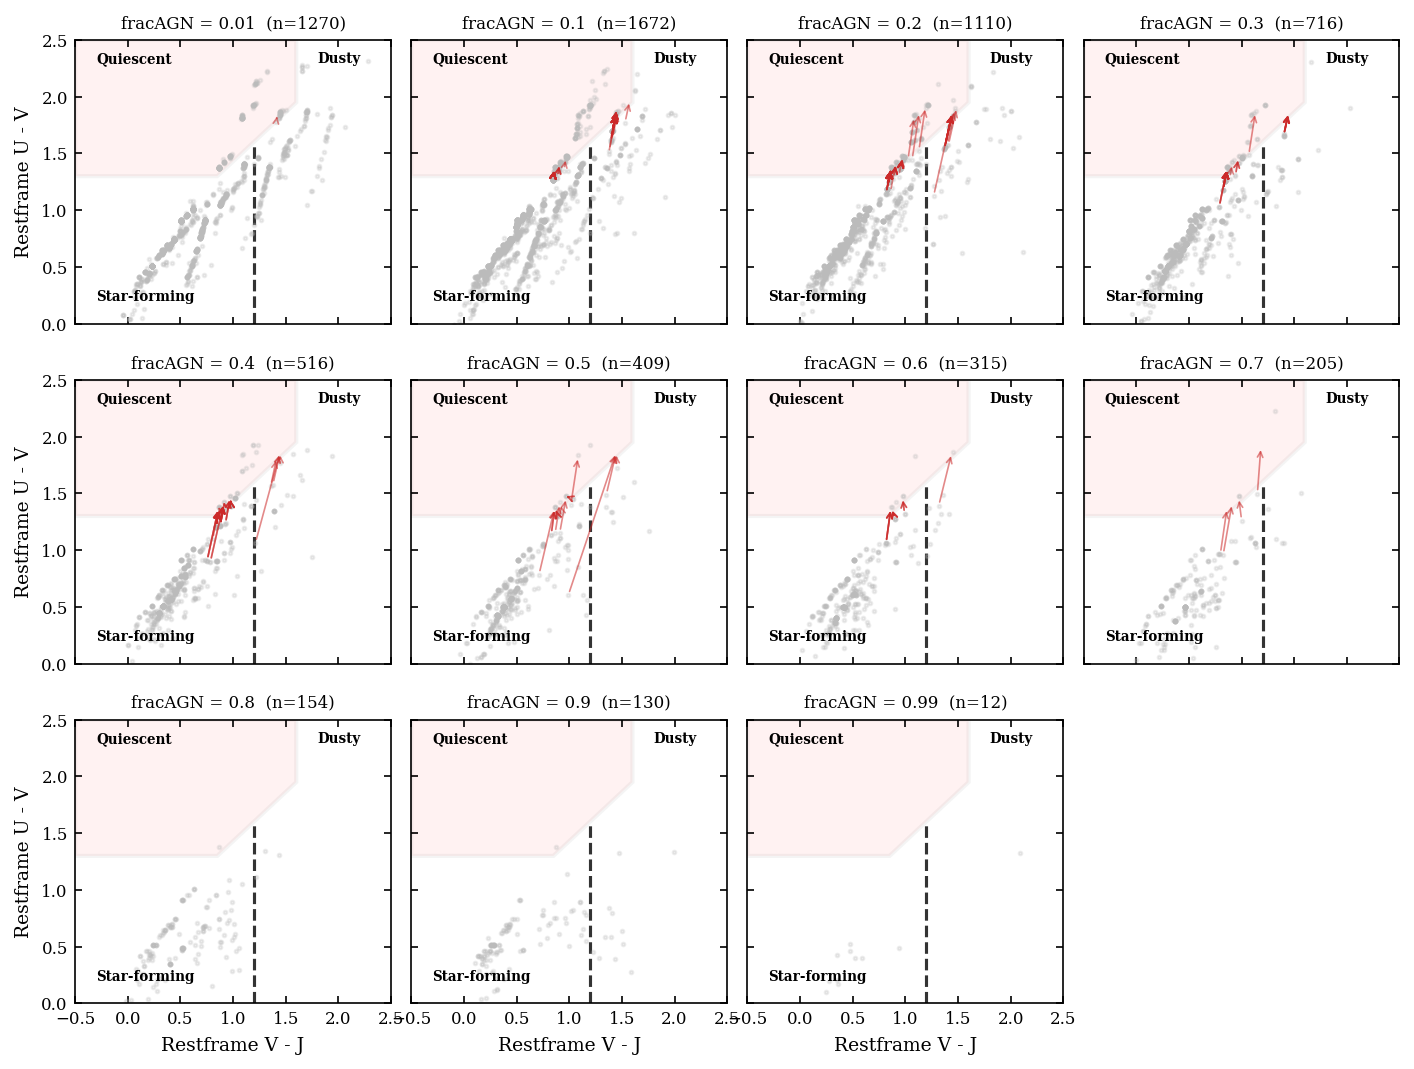

In [16]:
# Most of the fracAGN grid at once (11 non-zero values, 3x4 grid with one
# blank panel), individual-galaxy arrows, no corner stats -- to see the
# rise-and-fall directly in UVJ space rather than only in the trend plot.
frac_vals_nonzero = sorted(d['fracAGN'].unique())  # 11 grid points, 0.01..0.99
fig, axes = plt.subplots(3, 4, figsize=(9.5, 7.2), sharex=True, sharey=True)
for ax, fv in zip(axes.flat, frac_vals_nonzero):
    sub = d[d['fracAGN'] == fv]
    hidden_quiescent_map(ax, sub, f'fracAGN = {fv:g}  (n={len(sub)})', show_stats=False)
for ax in axes.flat[len(frac_vals_nonzero):]:
    ax.axis('off')
for ax in axes[:-1, :].flat: ax.set_xlabel('')
for ax in axes[:, 1:].flat: ax.set_ylabel('')
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_migration_fullgrid_individual.pdf'),
            dpi=300, bbox_inches='tight')
plt.show()

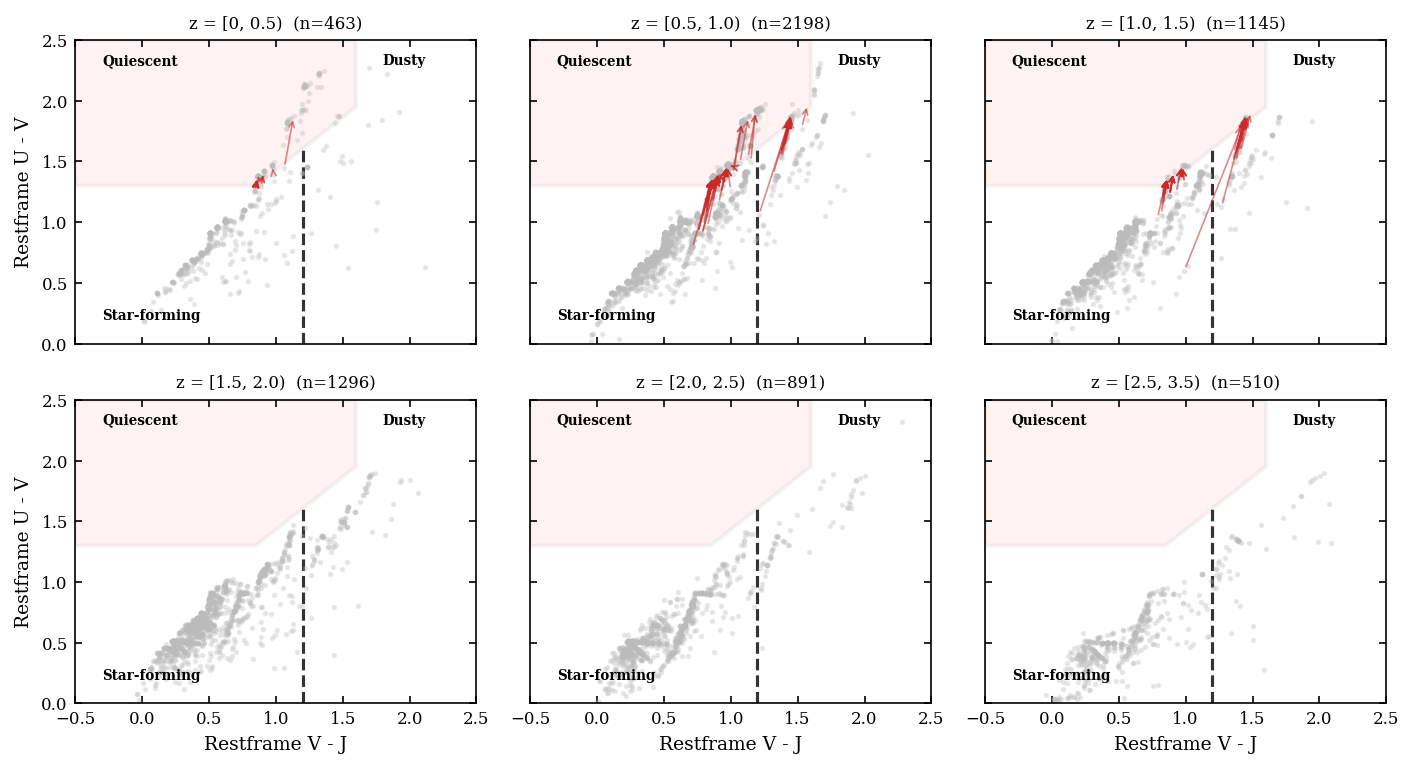

In [17]:
# Same argument applied to redshift: the original map used 4 coarse bins
# (last one lumping the whole z=1.5-3.5 null region together). Reusing the
# finer z_bins already defined in 9d (6 bins) gives more resolution, both in
# the active region and to show the null holds throughout z>1.5, not just as
# one blob. Individual-galaxy arrows, no corner stats.
fig, axes = plt.subplots(2, 3, figsize=(9.5, 5.2), sharex=True, sharey=True)
for ax, (z_min, z_max) in zip(axes.flat, z_bins):
    sub = d[(d[z_col] >= z_min) & (d[z_col] < z_max)]
    hidden_quiescent_map(ax, sub, f'z = [{z_min}, {z_max})  (n={len(sub)})', show_stats=False)
for ax in axes[:-1, :].flat: ax.set_xlabel('')
for ax in axes[:, 1:].flat: ax.set_ylabel('')
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_redshift_finerbins_individual.pdf'),
            dpi=300, bbox_inches='tight')
plt.show()

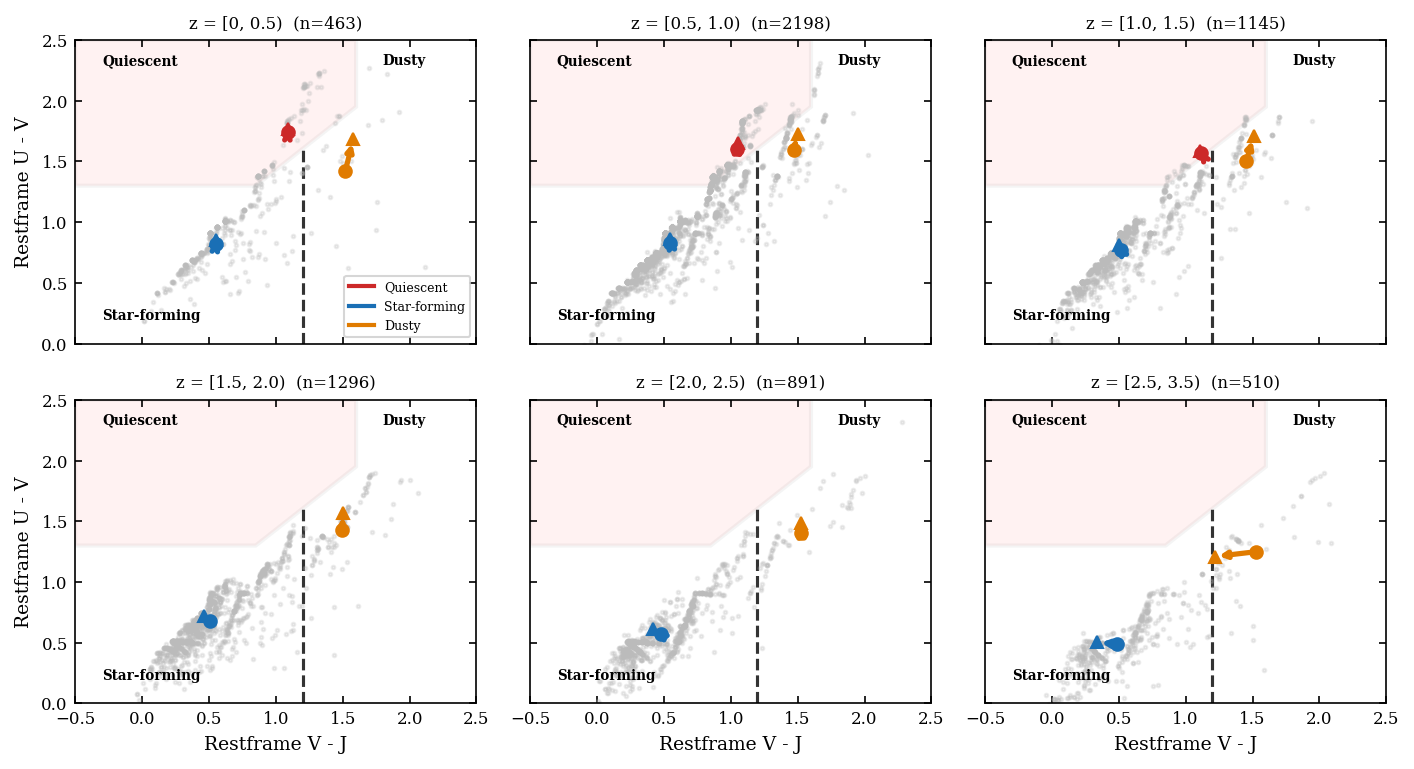

In [18]:
# Same finer z_bins, mean-shift arrow per region instead of per-galaxy arrows.
fig, axes = plt.subplots(2, 3, figsize=(9.5, 5.2), sharex=True, sharey=True)
for ax, (z_min, z_max) in zip(axes.flat, z_bins):
    sub = d[(d[z_col] >= z_min) & (d[z_col] < z_max)]
    hidden_quiescent_map(ax, sub, f'z = [{z_min}, {z_max})  (n={len(sub)})',
                          show_stats=False, mean_arrows=True)
legend_handles = [Line2D([0], [0], color=region_colors[cid], lw=2, label=region_names[cid])
                  for cid in [0, 1, 2]]
axes.flat[0].legend(handles=legend_handles, loc='lower right', fontsize=6)
for ax in axes[:-1, :].flat: ax.set_xlabel('')
for ax in axes[:, 1:].flat: ax.set_ylabel('')
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_redshift_finerbins_meanarrows.pdf'),
            dpi=300, bbox_inches='tight')
plt.show()

### 9e-ii. fracAGN distribution & movement trend (companion to Fig 7)

fracAGN is fit on a discrete CIGALE grid (12 values: 0, 0.01, 0.1, 0.2, ..., 0.9, 0.99), not a continuum -- there's no data between e.g. 0.1 and 0.2. This shows the sample-size distribution across that grid (top) and the mean UVJ vector-offset at each grid point (bottom), so Fig 7's four disjoint bins can be read against the full-resolution picture.

Spearman rank correlation (per-galaxy, n=6509): rho=0.488, p<1e-300


 fracAGN      N   offset             95% CI
    0.01   1270   0.0158   [0.0138, 0.0179]
    0.10   1672   0.0608   [0.0559, 0.0662]
    0.20   1110   0.0876   [0.0801, 0.0958]
    0.30    716   0.0871   [0.0810, 0.0939]
    0.40    516   0.1165   [0.1067, 0.1266]
    0.50    409   0.1425   [0.1285, 0.1586]
    0.60    315   0.1577   [0.1428, 0.1732]
    0.70    205   0.2397   [0.2124, 0.2671]
    0.80    154   0.2426   [0.1995, 0.2879]
    0.90    130   0.3116   [0.2348, 0.3897]
    0.99     12   0.7362   [0.3144, 1.3222]


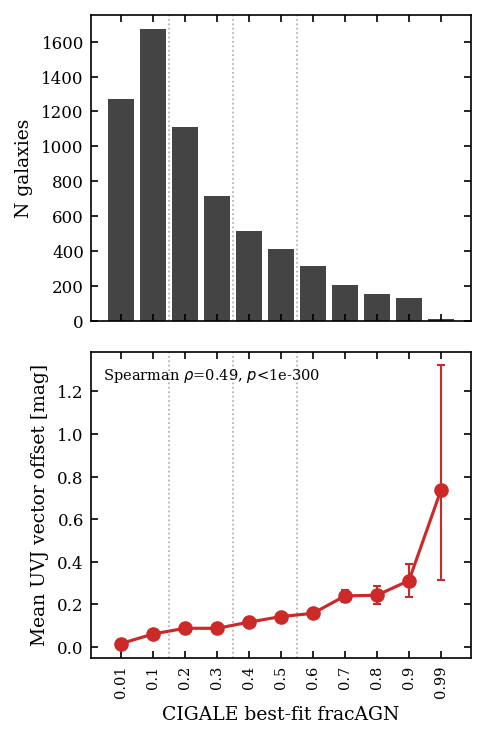

In [19]:
# Companion to the fracAGN maps above: how many galaxies sit at each discrete
# fracAGN grid value, and how the mean UVJ movement varies across that grid
# (finer resolution than the 4 disjoint FRAC_BINS used elsewhere).
from scipy import stats

frac_vals_nonzero = sorted(d['fracAGN'].unique())  # 11 grid points, 0.01..0.99
counts, offsets = [], []
for fv in frac_vals_nonzero:
    sub = d[d['fracAGN'] == fv]
    counts.append(len(sub))
    offsets.append(analysis.calculate_mean_vector_offset(
        sub['VJ_Decomposed'], sub['UV_Decomposed'], sub['VJ_Full'], sub['UV_Full']))

# Robustness check: N falls steeply as fracAGN rises (1672 -> 12), so the
# rising trend in the binned means above could just be small-sample noise in
# the sparse high-fracAGN points. Two checks that don't depend on the binning:
# (1) per-galaxy Spearman rank correlation (monotonic, no linearity
#     assumption, not dominated by the outlier-prone tail the way a fit to
#     11 bin-means would be); (2) bootstrap 95% CIs on each bin mean, so the
#     plot shows directly whether the rise survives the uncertainty.
dvj_all = (d['VJ_Decomposed'] - d['VJ_Full']).values
duv_all = (d['UV_Decomposed'] - d['UV_Full']).values
mask_all = ~np.isnan(dvj_all) & ~np.isnan(duv_all)
per_gal_offset = np.hypot(dvj_all[mask_all], duv_all[mask_all])
per_gal_frac = d['fracAGN'].values[mask_all]

rho, pval = stats.spearmanr(per_gal_frac, per_gal_offset)
pval_str = f"={pval:.1e}" if pval > 0 else "<1e-300"
print(f"Spearman rank correlation (per-galaxy, n={mask_all.sum()}): rho={rho:.3f}, p{pval_str}")

rng = np.random.default_rng(42)
n_boot = 2000
ci_lo, ci_hi = [], []
for fv in frac_vals_nonzero:
    sub = d[d['fracAGN'] == fv]
    dvj = (sub['VJ_Decomposed'] - sub['VJ_Full']).values
    duv = (sub['UV_Decomposed'] - sub['UV_Full']).values
    m = ~np.isnan(dvj) & ~np.isnan(duv)
    per_gal = np.hypot(dvj[m], duv[m])
    boot_means = rng.choice(per_gal, size=(n_boot, len(per_gal)), replace=True).mean(axis=1)
    lo, hi = np.percentile(boot_means, [2.5, 97.5])
    ci_lo.append(lo)
    ci_hi.append(hi)
ci_lo, ci_hi, offsets_arr = np.array(ci_lo), np.array(ci_hi), np.array(offsets)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3.31, 5.0), sharex=True)
x = np.arange(len(frac_vals_nonzero))

ax1.bar(x, counts, color='#444444')
ax1.set_ylabel('N galaxies')

ax2.errorbar(x, offsets_arr, yerr=[offsets_arr - ci_lo, ci_hi - offsets_arr],
             fmt='o-', color='#CC2929', ecolor='#CC2929', elinewidth=1, capsize=2)
ax2.set_ylabel('Mean UVJ vector offset [mag]')
ax2.set_xticks(x)
ax2.set_xticklabels([f'{v:g}' for v in frac_vals_nonzero], rotation=90, fontsize=7)
ax2.set_xlabel('CIGALE best-fit fracAGN')
ax2.text(0.03, 0.95, rf"Spearman $\rho$={rho:.2f}, $p${pval_str}",
         transform=ax2.transAxes, ha='left', va='top', fontsize=7)

# Mark the FRAC_BINS group edges on both panels, in x-index space, so this
# figure visually ties back to Fig 7's 4 discrete bins and makes the
# discreteness of the grid explicit.
for ax in (ax1, ax2):
    for lo, hi, _ in FRAC_BINS[:-1]:
        b = next(i - 0.5 for i, v in enumerate(frac_vals_nonzero) if v > hi)
        ax.axvline(b, color='#AAAAAA', linestyle=':', lw=0.8, zorder=1)

plt.tight_layout()
print(f"{'fracAGN':>8} {'N':>6} {'offset':>8} {'95% CI':>18}")
for fv, n, off, lo, hi in zip(frac_vals_nonzero, counts, offsets, ci_lo, ci_hi):
    print(f"{fv:8.2f} {n:6d} {off:8.4f}   [{lo:.4f}, {hi:.4f}]")
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_fracAGN_distribution_and_offset.pdf'),
            dpi=300, bbox_inches='tight')
plt.show()

### 9e-iii. Migration-to-quiescent trend across fracAGN (companion to Fig 7)

Unlike the vector-offset trend above (which rises monotonically -- more AGN light removed just means a bigger colour shift), the *migration rate into the quiescent wedge* is hump-shaped: a host needs enough AGN light to cross the boundary, but too much AGN light swamps the host colours entirely and the galaxy never lands cleanly in the wedge either way. This shows that shape at full fracAGN-grid resolution with bootstrap CIs, and tests whether the curvature itself is statistically real (quadratic vs. linear fracAGN term in a per-galaxy logistic fit, compared by AIC) rather than bin noise.

Linear fracAGN-only model:    AIC=2345.7
Quadratic fracAGN-only model: AIC=2225.6  (b1=+11.63, b2=-18.49)
Delta AIC (linear - quadratic) = 120.1 (>~2 favours the quadratic, i.e. the hump is real curvature, not noise)

 fracAGN  n_at_risk   mig_rate             95% CI
    0.01       1135     0.0009   [0.0000, 0.0026]
    0.10       1512     0.0582   [0.0456, 0.0708]
    0.20       1006     0.0954   [0.0775, 0.1153]
    0.30        668     0.0554   [0.0389, 0.0734]
    0.40        488     0.0840   [0.0594, 0.1066]
    0.50        400     0.0375   [0.0200, 0.0575]
    0.60        308     0.0357   [0.0162, 0.0584]
    0.70        202     0.0198   [0.0050, 0.0396]
    0.80        153     0.0000   [0.0000, 0.0000]
    0.90        129     0.0000   [0.0000, 0.0000]
    0.99         12     0.0000   [0.0000, 0.0000]


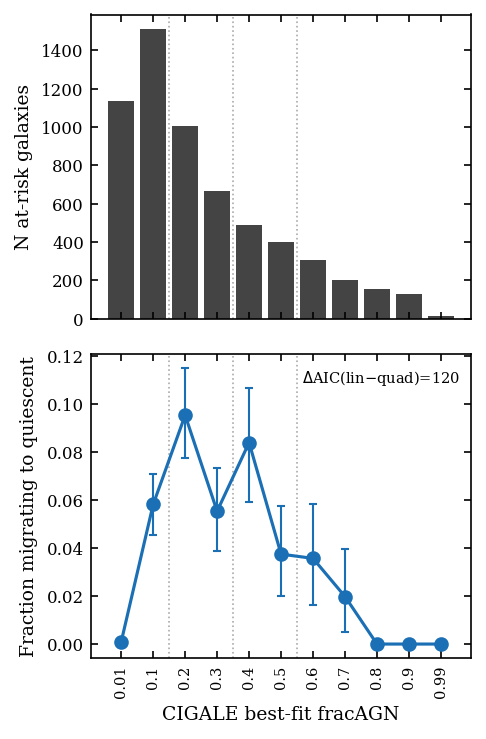

In [20]:
# Migration-to-quiescent trend across the fracAGN grid: among galaxies not
# already quiescent under full photometry ('at risk'), what fraction move
# into the quiescent wedge once the AGN component is removed, at each grid
# value? Same at_risk/moved_to_q framing as the contamination equation
# (cell 42-43 below), restricted to the fracAGN axis alone (no z term) so
# the curvature on this axis specifically can be tested.
from scipy.optimize import minimize

at_risk_all = d[d['cls_full'] != 0].copy()
at_risk_all['moved_to_q'] = (at_risk_all['cls_dec'] == 0).astype(int)

n_at_risk, migration_rate = [], []
mig_ci_lo, mig_ci_hi = [], []
rng2 = np.random.default_rng(7)
n_boot = 2000
for fv in frac_vals_nonzero:
    sub = at_risk_all[at_risk_all['fracAGN'] == fv]
    n = len(sub)
    n_at_risk.append(n)
    moved = sub['moved_to_q'].values
    migration_rate.append(moved.mean() if n else np.nan)
    if n:
        boot = rng2.choice(moved, size=(n_boot, n), replace=True).mean(axis=1)
        lo, hi = np.percentile(boot, [2.5, 97.5])
    else:
        lo = hi = np.nan
    mig_ci_lo.append(lo)
    mig_ci_hi.append(hi)
migration_rate = np.array(migration_rate)
mig_ci_lo, mig_ci_hi = np.array(mig_ci_lo), np.array(mig_ci_hi)

# Is the hump real curvature, or could a straight line fit just as well?
# Compare linear vs quadratic fracAGN terms in a per-galaxy logistic fit via AIC.
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def nll_linear(params, f, y):
    b0, b1 = params
    p = np.clip(sigmoid(b0 + b1 * f), 1e-10, 1 - 1e-10)
    return -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))

def nll_quad(params, f, y):
    b0, b1, b2 = params
    p = np.clip(sigmoid(b0 + b1 * f + b2 * f**2), 1e-10, 1 - 1e-10)
    return -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))

f_arr = at_risk_all['fracAGN'].values
y_arr = at_risk_all['moved_to_q'].values
fit_lin = minimize(nll_linear, np.zeros(2), args=(f_arr, y_arr), method='BFGS')
fit_quad = minimize(nll_quad, np.zeros(3), args=(f_arr, y_arr), method='BFGS')
aic_lin = 2 * 2 + 2 * fit_lin.fun
aic_quad = 2 * 3 + 2 * fit_quad.fun
print(f"Linear fracAGN-only model:    AIC={aic_lin:.1f}")
print(f"Quadratic fracAGN-only model: AIC={aic_quad:.1f}  "
      f"(b1={fit_quad.x[1]:+.2f}, b2={fit_quad.x[2]:+.2f})")
print(f"Delta AIC (linear - quadratic) = {aic_lin - aic_quad:.1f} "
      "(>~2 favours the quadratic, i.e. the hump is real curvature, not noise)")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3.31, 5.0), sharex=True)
x = np.arange(len(frac_vals_nonzero))

ax1.bar(x, n_at_risk, color='#444444')
ax1.set_ylabel('N at-risk galaxies')

ax2.errorbar(x, migration_rate, yerr=[migration_rate - mig_ci_lo, mig_ci_hi - migration_rate],
             fmt='o-', color='#1A6FB5', ecolor='#1A6FB5', elinewidth=1, capsize=2)
ax2.set_ylabel('Fraction migrating to quiescent')
ax2.set_xticks(x)
ax2.set_xticklabels([f'{v:g}' for v in frac_vals_nonzero], rotation=90, fontsize=7)
ax2.set_xlabel('CIGALE best-fit fracAGN')
ax2.text(0.97, 0.95, rf"$\Delta$AIC(lin$-$quad)={aic_lin - aic_quad:.0f}",
         transform=ax2.transAxes, ha='right', va='top', fontsize=7)

for ax in (ax1, ax2):
    for lo, hi, _ in FRAC_BINS[:-1]:
        b = next(i - 0.5 for i, v in enumerate(frac_vals_nonzero) if v > hi)
        ax.axvline(b, color='#AAAAAA', linestyle=':', lw=0.8, zorder=1)

plt.tight_layout()
print(f"\n{'fracAGN':>8} {'n_at_risk':>10} {'mig_rate':>10} {'95% CI':>18}")
for fv, n, r, lo, hi in zip(frac_vals_nonzero, n_at_risk, migration_rate, mig_ci_lo, mig_ci_hi):
    print(f"{fv:8.2f} {n:10d} {r:10.4f}   [{lo:.4f}, {hi:.4f}]")
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_fracAGN_migration_trend.pdf'),
            dpi=300, bbox_inches='tight')
plt.show()

### 9e-iv. Is the fracAGN hump actually a redshift effect?

fracAGN and redshift are not independent in this sample -- higher-fracAGN galaxies skew systematically higher-z, and the migration-to-quiescent effect is already known to be null above z~1.5 (section 9d, Angle 1). So before trusting the hump-shaped fracAGN trend above, need to check whether it's actually being driven (or amplified) by high-fracAGN galaxies simply being at redshifts where the effect can't operate at all, rather than a genuine 'too much AGN light swamps the host' saturation effect.

fracAGN vs z Spearman (all AGN hosts, n=6509): rho=0.322, p=1.25e-156



z < 1.5 only (n=3310): quadratic vs linear AIC delta = 99.1 (b1=+12.78, b2=-17.86); full-sample delta was 120.1 (b1=+11.63, b2=-18.49)
-> curvature survives (and coefficients are similar) within the active regime, so the hump is not solely a redshift dilution artefact,
   though pooling in the z>1.5 null population does suppress the apparent rate at high fracAGN (rates are higher throughout when restricted to z<1.5).

 fracAGN  median_z  rate_all  n_lowz  rate_z<1.5
    0.01     0.958    0.0009     746      0.0013
    0.10     0.962    0.0582    1033      0.0852
    0.20     1.149    0.0954     605      0.1587
    0.30     1.367    0.0554     349      0.1060
    0.40     1.511    0.0840     229      0.1790
    0.50     1.748    0.0375     141      0.1064
    0.60     1.843    0.0357      99      0.1111
    0.70     1.851    0.0198      66      0.0606
    0.80     1.942    0.0000      33      0.0000
    0.90     2.122    0.0000       9      0.0000
    0.99     2.528    0.0000       0  

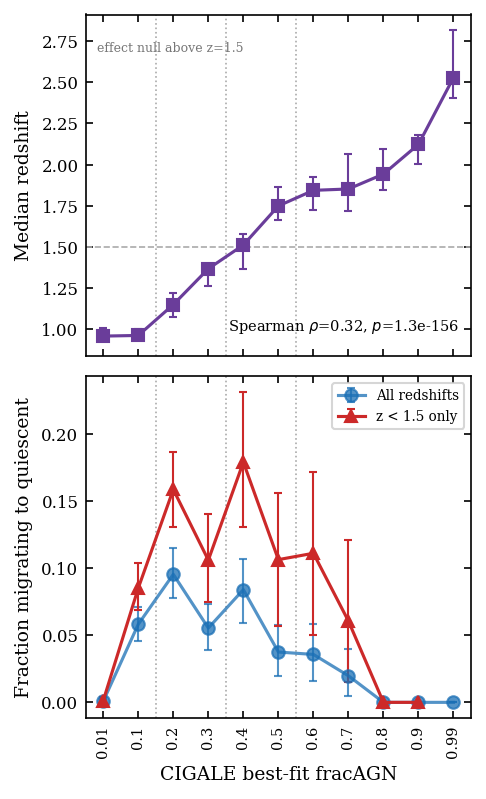

In [21]:
# Check 1: does fracAGN correlate with redshift at all?
rho_fz, p_fz = stats.spearmanr(d['fracAGN'], d[z_col])
print(f"fracAGN vs z Spearman (all AGN hosts, n={len(d)}): "
      f"rho={rho_fz:.3f}, p={p_fz:.2e}")

z_med, z_ci_lo, z_ci_hi = [], [], []
rng3 = np.random.default_rng(11)
for fv in frac_vals_nonzero:
    zvals = d.loc[d['fracAGN'] == fv, z_col].values
    z_med.append(np.median(zvals))
    boot = rng3.choice(zvals, size=(n_boot, len(zvals)), replace=True)
    lo, hi = np.percentile(np.median(boot, axis=1), [2.5, 97.5])
    z_ci_lo.append(lo)
    z_ci_hi.append(hi)
z_med, z_ci_lo, z_ci_hi = np.array(z_med), np.array(z_ci_lo), np.array(z_ci_hi)

# Check 2: does the migration-rate hump survive within just the active
# (z < 1.5) regime, where the effect isn't structurally forced to zero?
at_risk_lowz = at_risk_all[at_risk_all[z_col] < 1.5]
n_lowz, rate_lowz, ci_lo_lowz, ci_hi_lowz = [], [], [], []
rng4 = np.random.default_rng(13)
for fv in frac_vals_nonzero:
    sub = at_risk_lowz[at_risk_lowz['fracAGN'] == fv]
    n = len(sub)
    n_lowz.append(n)
    moved = sub['moved_to_q'].values
    if n:
        rate_lowz.append(moved.mean())
        boot = rng4.choice(moved, size=(n_boot, n), replace=True).mean(axis=1)
        lo, hi = np.percentile(boot, [2.5, 97.5])
    else:
        rate_lowz.append(np.nan)
        lo = hi = np.nan
    ci_lo_lowz.append(lo)
    ci_hi_lowz.append(hi)
rate_lowz = np.array(rate_lowz)
ci_lo_lowz, ci_hi_lowz = np.array(ci_lo_lowz), np.array(ci_hi_lowz)

# Same linear-vs-quadratic AIC test as before, restricted to z < 1.5
f_lowz = at_risk_lowz['fracAGN'].values
y_lowz = at_risk_lowz['moved_to_q'].values
fit_lin_lowz = minimize(nll_linear, np.zeros(2), args=(f_lowz, y_lowz), method='BFGS')
fit_quad_lowz = minimize(nll_quad, np.zeros(3), args=(f_lowz, y_lowz), method='BFGS')
aic_lin_lowz = 2 * 2 + 2 * fit_lin_lowz.fun
aic_quad_lowz = 2 * 3 + 2 * fit_quad_lowz.fun
print(f"\nz < 1.5 only (n={len(at_risk_lowz)}): quadratic vs linear AIC "
      f"delta = {aic_lin_lowz - aic_quad_lowz:.1f} "
      f"(b1={fit_quad_lowz.x[1]:+.2f}, b2={fit_quad_lowz.x[2]:+.2f}); "
      f"full-sample delta was {aic_lin - aic_quad:.1f} "
      f"(b1={fit_quad.x[1]:+.2f}, b2={fit_quad.x[2]:+.2f})")
print("-> curvature survives (and coefficients are similar) within the "
      "active regime, so the hump is not solely a redshift dilution artefact,\n"
      "   though pooling in the z>1.5 null population does suppress the "
      "apparent rate at high fracAGN (rates are higher throughout when "
      "restricted to z<1.5).")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3.31, 5.4), sharex=True)
x = np.arange(len(frac_vals_nonzero))

ax1.errorbar(x, z_med, yerr=[z_med - z_ci_lo, z_ci_hi - z_med],
             fmt='s-', color='#6A3D9A', ecolor='#6A3D9A', elinewidth=1, capsize=2)
ax1.axhline(1.5, color='#AAAAAA', linestyle='--', lw=0.8)
ax1.text(0.03, 0.92, 'effect null above z=1.5', transform=ax1.transAxes,
         fontsize=6, color='#777777', va='top')
ax1.set_ylabel('Median redshift')
ax1.text(0.97, 0.06, rf"Spearman $\rho$={rho_fz:.2f}, $p$={p_fz:.1e}",
         transform=ax1.transAxes, ha='right', va='bottom', fontsize=7)

ax2.errorbar(x, migration_rate, yerr=[migration_rate - mig_ci_lo, mig_ci_hi - migration_rate],
             fmt='o-', color='#1A6FB5', ecolor='#1A6FB5', elinewidth=1, capsize=2,
             label='All redshifts', alpha=0.75)
ax2.errorbar(x, rate_lowz, yerr=[rate_lowz - ci_lo_lowz, ci_hi_lowz - rate_lowz],
             fmt='^-', color='#CC2929', ecolor='#CC2929', elinewidth=1, capsize=2,
             label='z < 1.5 only')
ax2.set_ylabel('Fraction migrating to quiescent')
ax2.set_xticks(x)
ax2.set_xticklabels([f'{v:g}' for v in frac_vals_nonzero], rotation=90, fontsize=7)
ax2.set_xlabel('CIGALE best-fit fracAGN')
ax2.legend(fontsize=6.5, loc='upper right')

for ax in (ax1, ax2):
    for lo, hi, _ in FRAC_BINS[:-1]:
        b = next(i - 0.5 for i, v in enumerate(frac_vals_nonzero) if v > hi)
        ax.axvline(b, color='#AAAAAA', linestyle=':', lw=0.8, zorder=1)

plt.tight_layout()
print(f"\n{'fracAGN':>8} {'median_z':>9} {'rate_all':>9} {'n_lowz':>7} {'rate_z<1.5':>11}")
for fv, zm, ra, nlz, rl in zip(frac_vals_nonzero, z_med, migration_rate, n_lowz, rate_lowz):
    print(f"{fv:8.2f} {zm:9.3f} {ra:9.4f} {nlz:7d} {rl:11.4f}")
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_fracAGN_redshift_confound.pdf'),
            dpi=300, bbox_inches='tight')
plt.show()

### 9f. All class transitions & the dusty-region pipeline

First, the 9e map design extended to **every** class transition (coloured by type). Then the hidden-quiescent pipeline applied to the **dusty region**: before/after dusty fractions vs redshift and fracAGN, and a comparison of the fracAGN distributions of the four migration populations — testing whether the dusty-region migrations are a different AGN effect (torus-dominated reddening at high AGN contribution) from the quiescent recoveries.

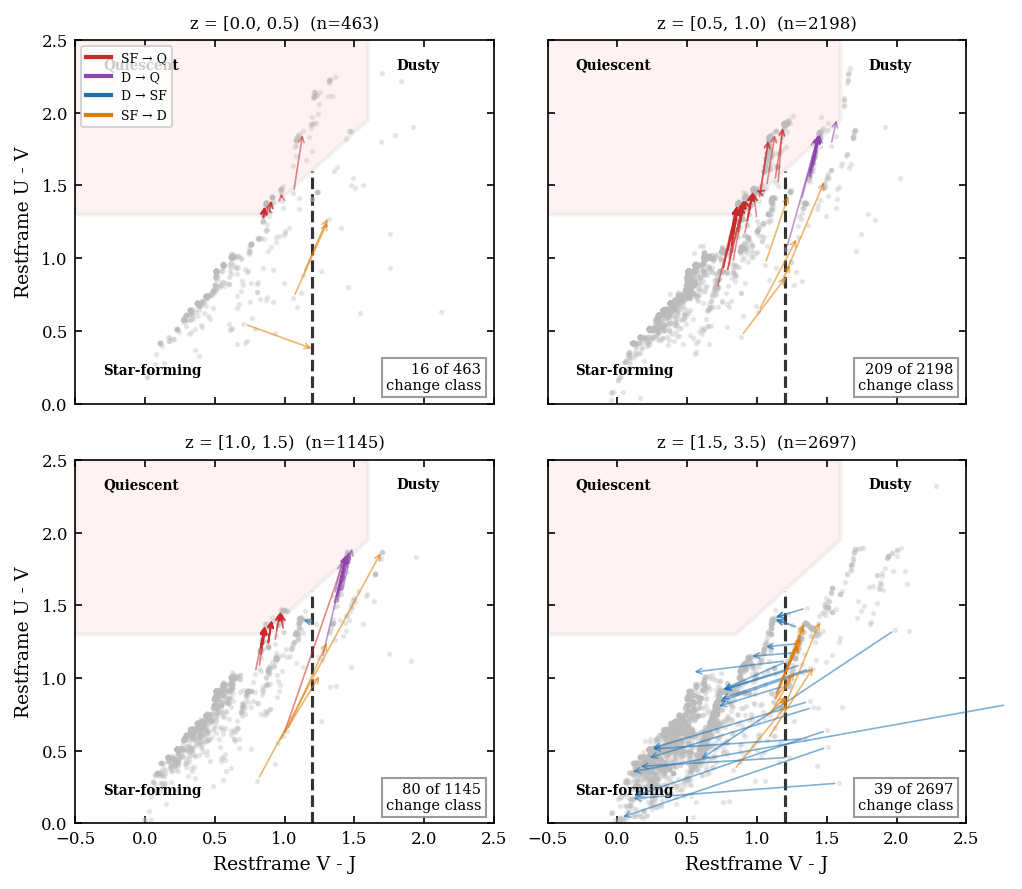

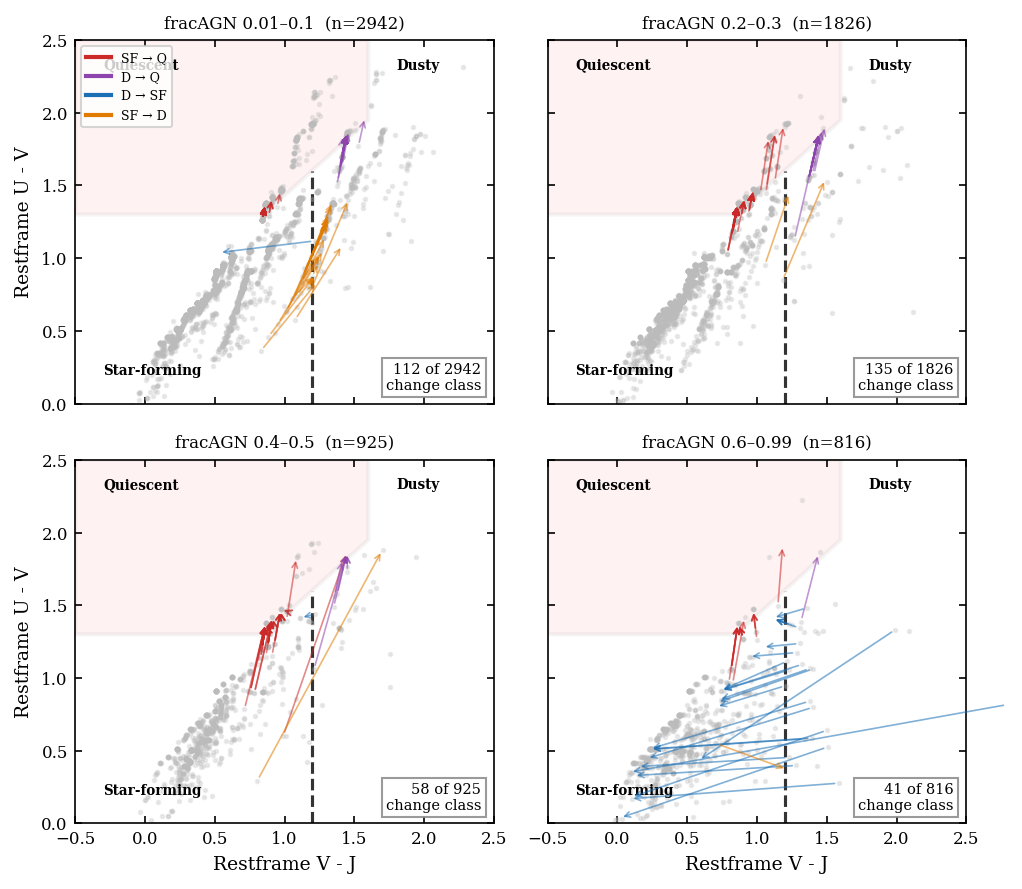

In [22]:
# All class transitions in UVJ space: same map design as 9e but with every
# migration drawn, coloured by transition type.
all_transition_styles = {
    (1, 0): ('#CC2929', 'SF → Q'),
    (2, 0): ('#8E44AD', 'D → Q'),
    (2, 1): ('#1A6FB5', 'D → SF'),
    (1, 2): ('#E07B00', 'SF → D'),
}

def all_moves_map(ax, sub, title):
    visualization.plot_uvj_diagram([], [], ax=ax, title="")
    ax.scatter(sub['VJ_Full'], sub['UV_Full'], c='#BBBBBB', s=3, alpha=0.25, zorder=2)
    n_moved = 0
    for (c_from, c_to), (color, lab) in all_transition_styles.items():
        m = sub[(sub['cls_full'] == c_from) & (sub['cls_dec'] == c_to)]
        n_moved += len(m)
        for _, row in m.iterrows():
            ax.annotate('', xy=(row['VJ_Decomposed'], row['UV_Decomposed']),
                        xytext=(row['VJ_Full'], row['UV_Full']),
                        arrowprops=dict(arrowstyle='->', color=color, lw=0.8, alpha=0.55))
    ax.text(0.97, 0.03, f'{n_moved} of {len(sub)}\nchange class',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=7,
            bbox=dict(facecolor='white', edgecolor='#888888', alpha=0.85, pad=2))
    ax.set_title(title, fontsize=8)
    for txt in ax.texts[:-1]:
        txt.set_fontsize(6.5)

transition_handles = [Line2D([0], [0], color=c, lw=2, label=lab)
                      for c, lab in all_transition_styles.values()]

# Across redshift
fig, axes = plt.subplots(2, 2, figsize=(6.85, 6.0), sharex=True, sharey=True)
for ax, (z_min, z_max) in zip(axes.flat, map_z_bins):
    sub = d[(d[z_col] >= z_min) & (d[z_col] < z_max)]
    all_moves_map(ax, sub, f'z = [{z_min}, {z_max})  (n={len(sub)})')
axes.flat[0].legend(handles=transition_handles, loc='upper left', fontsize=6)
for ax in axes[0, :]: ax.set_xlabel('')
for ax in axes[:, 1]: ax.set_ylabel('')
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_all_transitions_maps_redshift.pdf'), dpi=300, bbox_inches='tight')
plt.show()

# Across fracAGN bins
fig, axes = plt.subplots(2, 2, figsize=(6.85, 6.0), sharex=True, sharey=True)
for ax, (lo, hi, label) in zip(axes.flat, FRAC_BINS):
    sub = d[(d['fracAGN'] > lo) & (d['fracAGN'] <= hi)]
    all_moves_map(ax, sub, f'fracAGN {label}  (n={len(sub)})')
axes.flat[0].legend(handles=transition_handles, loc='upper left', fontsize=6)
for ax in axes[0, :]: ax.set_xlabel('')
for ax in axes[:, 1]: ax.set_ylabel('')
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_all_transitions_maps_fracAGN.pdf'), dpi=300, bbox_inches='tight')
plt.show()

Dusty fraction, full -> decomposed:
  z=[0,0.5):   5.2% ->   5.8% (+0.6 pp)
  z=[0.5,1.0):   6.4% ->   4.4% (-2.0 pp)
  z=[1.0,1.5):   7.2% ->   4.7% (-2.4 pp)
  z=[1.5,2.0):   7.9% ->   7.7% (-0.2 pp)
  z=[2.0,2.5):   6.6% ->   7.1% (+0.4 pp)
  z=[2.5,3.5):  10.2% ->   8.2% (-2.0 pp)
  fracAGN 0.01–0.1:  10.5% ->   9.8% (-0.8 pp)
  fracAGN 0.2–0.3:   4.9% ->   3.6% (-1.4 pp)
  fracAGN 0.4–0.5:   3.4% ->   2.7% (-0.6 pp)
  fracAGN 0.6–0.99:   3.8% ->   0.7% (-3.1 pp)


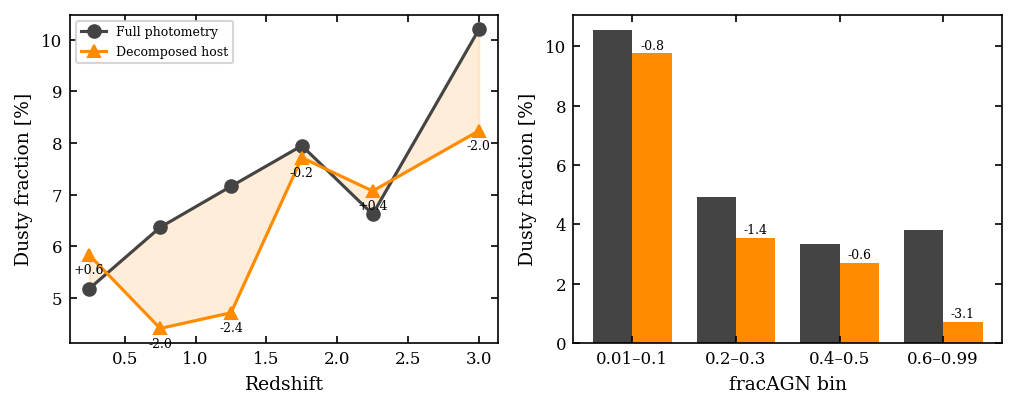

In [23]:
# Dusty-region pipeline: same before/after fraction analysis as the hidden-quiescent
# one, but for the dusty region. Note the sign: the DUSTY fraction DECREASES after
# decomposition — AGN light (red torus continuum) fakes dusty colours.
fig, axes = plt.subplots(1, 2, figsize=(6.85, 2.8))

# vs redshift
d_full_z, d_dec_z, zm = [], [], []
for z_min, z_max in z_bins:
    b = d[(d[z_col] >= z_min) & (d[z_col] < z_max)]
    if len(b) < 20: continue
    d_full_z.append(100 * (b['cls_full'] == 2).mean())
    d_dec_z.append(100 * (b['cls_dec'] == 2).mean())
    zm.append(0.5 * (z_min + z_max))
axes[0].plot(zm, d_full_z, 'o-', color='#444444',    label='Full photometry')
axes[0].plot(zm, d_dec_z,  '^-', color='darkorange', label='Decomposed host')
axes[0].fill_between(zm, d_full_z, d_dec_z, color='darkorange', alpha=0.15)
for zi, (df_, dd_) in enumerate(zip(d_full_z, d_dec_z)):
    axes[0].annotate(f'{dd_ - df_:+.1f}', (zm[zi], dd_), textcoords='offset points',
                     xytext=(0, -9), ha='center', fontsize=6)
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('Dusty fraction [%]')
axes[0].legend(fontsize=6)

# vs fracAGN bin
d_full_f, d_dec_f, labels = [], [], []
for lo, hi, label in FRAC_BINS:
    b = d[(d['fracAGN'] > lo) & (d['fracAGN'] <= hi)]
    d_full_f.append(100 * (b['cls_full'] == 2).mean())
    d_dec_f.append(100 * (b['cls_dec'] == 2).mean())
    labels.append(label)
x = np.arange(len(labels))
w = 0.38
axes[1].bar(x - w/2, d_full_f, w, color='#444444',    label='Full photometry')
axes[1].bar(x + w/2, d_dec_f,  w, color='darkorange', label='Decomposed host')
for xi, (df_, dd_) in enumerate(zip(d_full_f, d_dec_f)):
    axes[1].annotate(f'{dd_ - df_:+.1f}', (xi + w/2, dd_), textcoords='offset points',
                     xytext=(0, 2), ha='center', fontsize=6)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_xlabel('fracAGN bin')
axes[1].set_ylabel('Dusty fraction [%]')

print('Dusty fraction, full -> decomposed:')
for (z_min, z_max), df_, dd_ in zip(z_bins, d_full_z, d_dec_z):
    print(f'  z=[{z_min},{z_max}): {df_:5.1f}% -> {dd_:5.1f}% ({dd_ - df_:+.1f} pp)')
for label, df_, dd_ in zip(labels, d_full_f, d_dec_f):
    print(f'  fracAGN {label}: {df_:5.1f}% -> {dd_:5.1f}% ({dd_ - df_:+.1f} pp)')
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_dusty_fraction_evolution.pdf'), dpi=300, bbox_inches='tight')
plt.show()

   Group     n  med fracAGN   med z  med lmass
  SF → Q   215         0.20    0.86       9.08
   D → Q    78         0.10    0.95       9.96
  D → SF    27         0.80    2.71       9.48
  SF → D    26         0.10    1.69       9.35


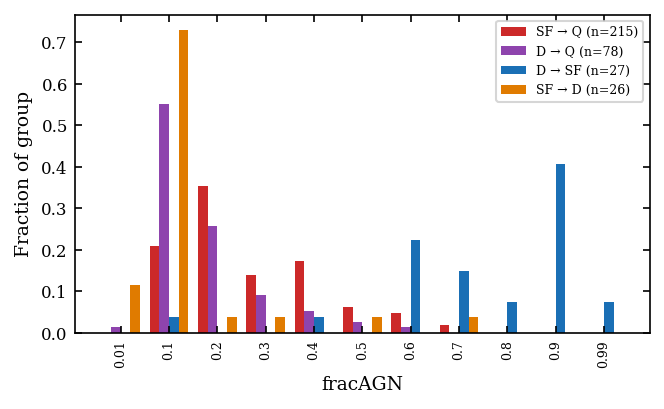

In [24]:
# Dusty movers: is this a different AGN effect? Compare fracAGN distributions of the
# three migration populations. If dusty-region migrations are driven by a different
# AGN regime (e.g. torus-dominated reddening at high AGN contribution) the dusty
# leavers should cluster at much higher fracAGN than the quiescent movers.
mover_groups = {
    'SF → Q':  (d['cls_full'] == 1) & (d['cls_dec'] == 0),
    'D → Q':   (d['cls_full'] == 2) & (d['cls_dec'] == 0),
    'D → SF':  (d['cls_full'] == 2) & (d['cls_dec'] == 1),
    'SF → D':  (d['cls_full'] == 1) & (d['cls_dec'] == 2),
}
group_colors = {'SF → Q': '#CC2929', 'D → Q': '#8E44AD', 'D → SF': '#1A6FB5', 'SF → D': '#E07B00'}

frac_vals = sorted(d['fracAGN'].unique())
x = np.arange(len(frac_vals))
n_g = len(mover_groups)
w = 0.8 / n_g
fig, ax = plt.subplots(figsize=(4.5, 2.8))
print(f"{'Group':>8} {'n':>5} {'med fracAGN':>12} {'med z':>7} {'med lmass':>10}")
for gi, (gname, gmask) in enumerate(mover_groups.items()):
    g = d[gmask]
    if len(g) == 0: continue
    dist = g['fracAGN'].value_counts(normalize=True).reindex(frac_vals, fill_value=0)
    ax.bar(x + (gi - (n_g - 1) / 2) * w, dist.values, w, color=group_colors[gname],
           label=f'{gname} (n={len(g)})')
    lm = g.loc[g['lmass'] > 0, 'lmass']
    print(f"{gname:>8} {len(g):>5} {g['fracAGN'].median():>12.2f} {g[z_col].median():>7.2f} {lm.median():>10.2f}")
ax.set_xticks(x)
ax.set_xticklabels([f'{v:g}' for v in frac_vals], rotation=90, fontsize=6)
ax.set_xlabel('fracAGN')
ax.set_ylabel('Fraction of group')
ax.legend(fontsize=6)
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_dusty_mover_fracAGN.pdf'), dpi=300, bbox_inches='tight')
plt.show()

### 9g. Practical Contamination Estimates

A 2D lookup table: for a given redshift bin and CIGALE best-fit AGN fraction
(fracAGN) bin, how much is the measured quiescent fraction biased, and what's
the mean UVJ colour-space displacement? Meant as a practical "how do I use
this" reference for someone correcting their own AGN-host sample, not just a
diagnostic for this paper.

In [25]:
# Practical contamination estimate: quiescent-fraction bias (pp) and mean UVJ
# vector offset (mag), jointly binned by redshift and fracAGN. Reuses the same
# d / cls_full / cls_dec from 9c and the same FRAC_BINS / z_bins / z_col as
# the rest of section 9 - no new bin definitions.
rows = []
for zlo, zhi in z_bins:
    for flo, fhi, flabel in FRAC_BINS:
        sub = d[(d[z_col] >= zlo) & (d[z_col] < zhi) &
                (d['fracAGN'] > flo) & (d['fracAGN'] <= fhi)]
        n = len(sub)
        if n > 0:
            q_full = 100 * (sub['cls_full'] == 0).mean()
            q_dec  = 100 * (sub['cls_dec'] == 0).mean()
            offset = analysis.calculate_mean_vector_offset(
                sub['VJ_Decomposed'], sub['UV_Decomposed'],
                sub['VJ_Full'], sub['UV_Full'])
        else:
            q_full = q_dec = offset = np.nan
        rows.append({'z_bin': f'{zlo}-{zhi}', 'fracAGN_bin': flabel, 'N': n,
                     'Q_bias_pp': q_dec - q_full if n else np.nan,
                     'Vector_offset_mag': offset})
contam_df = pd.DataFrame(rows)

print(f"Total N across all bins: {contam_df['N'].sum()} (should be {len(d)})")

bias_grid = contam_df.pivot(index='z_bin', columns='fracAGN_bin', values='Q_bias_pp')
offset_grid = contam_df.pivot(index='z_bin', columns='fracAGN_bin', values='Vector_offset_mag')
n_grid = contam_df.pivot(index='z_bin', columns='fracAGN_bin', values='N')

print('---')
print('Quiescent-fraction bias (pp, decomposed - full):')
display(bias_grid.round(1))
print('---')
print('Mean UVJ vector offset (mag):')
display(offset_grid.round(3))
print('---')
print('N per bin:')
display(n_grid)

contam_df.to_csv(os.path.join(config.PROCESSED_DATA_DIR, 'Contamination_zFracAGN_long.csv'), index=False)
bias_grid.to_csv(os.path.join(config.PROCESSED_DATA_DIR, 'Contamination_QuiescentBias_zFracAGN.csv'))
offset_grid.to_csv(os.path.join(config.PROCESSED_DATA_DIR, 'Contamination_VectorOffset_zFracAGN.csv'))

Total N across all bins: 6503 (should be 6509)
---
Quiescent-fraction bias (pp, decomposed - full):


fracAGN_bin,0.01–0.1,0.2–0.3,0.4–0.5,0.6–0.99
z_bin,,,,
0-0.5,1.3,5.8,9.1,0.0
0.5-1.0,5.3,14.4,16.2,10.8
1.0-1.5,3.8,10.0,10.9,3.0
1.5-2.0,0.0,0.0,0.0,0.0
2.0-2.5,0.0,0.0,0.0,0.0
2.5-3.5,0.0,0.0,0.0,0.0


---
Mean UVJ vector offset (mag):


fracAGN_bin,0.01–0.1,0.2–0.3,0.4–0.5,0.6–0.99
z_bin,,,,
0-0.5,0.026,0.084,0.091,0.385
0.5-1.0,0.032,0.074,0.087,0.083
1.0-1.5,0.041,0.089,0.115,0.116
1.5-2.0,0.058,0.090,0.140,0.211
2.0-2.5,0.059,0.101,0.154,0.203
2.5-3.5,0.078,0.123,0.176,0.392


---
N per bin:


fracAGN_bin,0.01–0.1,0.2–0.3,0.4–0.5,0.6–0.99
z_bin,,,,
0-0.5,314,120,22,7
0.5-1.0,1233,625,229,111
1.0-1.5,527,361,156,101
1.5-2.0,478,365,244,209
2.0-2.5,276,241,181,193
2.5-3.5,114,113,93,190


A companion equation: a per-galaxy logistic model of the reclassification
probability, fit to the underlying 6,000+ galaxy sample rather than just the
24 coarse bins above (the fracAGN-dependence genuinely differs by redshift
row, so a single 1D curve through the binned table wouldn't be honest).

In [26]:
# Companion equation: per-galaxy logistic model for P(reclassified to
# quiescent | fracAGN, z), fit by maximum likelihood on all "at-risk"
# galaxies (fracAGN>0, not already quiescent in full photometry - only
# these can be reclassified into the wedge). Uses far more statistical
# power than fitting a curve through the 24 binned points above.
from scipy.optimize import minimize

at_risk = d[d['cls_full'] != 0].dropna(subset=['fracAGN', z_col]).copy()
at_risk['moved_to_q'] = (at_risk['cls_dec'] == 0).astype(float)
X_frac = at_risk['fracAGN'].values
X_z = at_risk[z_col].values
y_moved = at_risk['moved_to_q'].values

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def neg_log_likelihood(params, frac, z, y):
    b0, b1, b2, b3, b4 = params
    logits = b0 + b1*frac + b2*frac**2 + b3*z + b4*z**2
    p = np.clip(sigmoid(logits), 1e-10, 1 - 1e-10)
    return -np.sum(y*np.log(p) + (1 - y)*np.log(1 - p))

fit = minimize(neg_log_likelihood, np.zeros(5), args=(X_frac, X_z, y_moved), method='BFGS')
b0, b1, b2, b3, b4 = fit.x
print(f"Converged: {fit.success} ({fit.message})")
print(f"Coefficients [b0, b1, b2, b3, b4]: {np.round(fit.x, 4)}")

# McFadden's pseudo R^2 against an intercept-only null model
p_null = y_moved.mean()
ll_null = np.sum(y_moved*np.log(p_null) + (1 - y_moved)*np.log(1 - p_null))
ll_model = -fit.fun
pseudo_r2 = 1 - ll_model / ll_null
print(f"McFadden's pseudo R^2: {pseudo_r2:.3f}  (N={len(at_risk)}, {int(y_moved.sum())} reclassified)")

def predict_p(frac, z):
    return sigmoid(b0 + b1*frac + b2*frac**2 + b3*z + b4*z**2)

# Goodness-of-fit check: predicted vs empirical, same (z, fracAGN) bins as the table above
print(f"\n{'z bin':>10} {'fracAGN bin':>12} {'predicted':>10} {'empirical':>10} {'n':>6}")
for flo, fhi, flabel, fcenter in [(0.005, 0.15, '0.01-0.1', 0.0775), (0.15, 0.35, '0.2-0.3', 0.25),
                                   (0.35, 0.55, '0.4-0.5', 0.45), (0.55, 1.00, '0.6-0.99', 0.775)]:
    for zlo, zhi in z_bins:
        zc = (zlo + zhi) / 2
        sub = at_risk[(at_risk[z_col] >= zlo) & (at_risk[z_col] < zhi) &
                      (at_risk['fracAGN'] > flo) & (at_risk['fracAGN'] <= fhi)]
        emp = sub['moved_to_q'].mean() if len(sub) else np.nan
        print(f"{zlo}-{zhi:>6} {flabel:>12} {predict_p(fcenter, zc):>10.3f} {emp:>10.3f} {len(sub):>6}")

# A couple of illustrative points for the paper text
print("\nIllustrative predictions:")
for fc, zc in [(0.3, 0.75), (0.45, 0.75), (0.3, 1.75)]:
    print(f"  fracAGN={fc}, z={zc}: P(reclassified) = {predict_p(fc, zc):.3f}")

Converged: True (Optimization terminated successfully.)
Coefficients [b0, b1, b2, b3, b4]: [-10.1558  13.3593 -18.6872  16.0744  -9.3358]
McFadden's pseudo R^2: 0.257  (N=6013, 293 reclassified)

     z bin  fracAGN bin  predicted  empirical      n
0-   0.5     0.01-0.1      0.003      0.016    256
0.5-   1.0     0.01-0.1      0.081      0.064   1012
1.0-   1.5     0.01-0.1      0.024      0.039    511
1.5-   2.0     0.01-0.1      0.000      0.000    478
2.0-   2.5     0.01-0.1      0.000      0.000    276
2.5-   3.5     0.01-0.1      0.000      0.000    114
0-   0.5      0.2-0.3      0.010      0.071     99
0.5-   1.0      0.2-0.3      0.235      0.179    503
1.0-   1.5      0.2-0.3      0.077      0.102    352
1.5-   2.0      0.2-0.3      0.000      0.000    365
2.0-   2.5      0.2-0.3      0.000      0.000    241
2.5-   3.5      0.2-0.3      0.000      0.000    113
0-   0.5      0.4-0.5      0.011      0.118     17
0.5-   1.0      0.4-0.5      0.245      0.186    199
1.0-   1.5     

## Export: Paper-Required Figures

Copies the subset of plots referenced by `Context/AGNPaper/paper.tex` into `outputs/PaperFigures/`, so that folder always reflects exactly what the paper needs (see `config.PAPER_FIGURE_MANIFEST`).

In [27]:
# Export the subset of plots required by Context/AGNPaper/paper.tex into
# outputs/PaperFigures/, and - if the gitignored Overleaf checkout is present
# locally - straight into its Images/TheoreticalModelPlots/ folder too, so
# the paper never silently references a stale/missing figure.
# (see config.PAPER_FIGURE_MANIFEST for the full list)
import shutil

os.makedirs(config.PAPER_FIGURES_DIR, exist_ok=True)
overleaf_present = os.path.isdir(config.AGNPAPER_DIR)
if overleaf_present:
    os.makedirs(config.PAPER_OVERLEAF_IMAGES_DIR, exist_ok=True)

copied, missing = [], []
for paper_filename, rel_source in config.PAPER_FIGURE_MANIFEST.items():
    src_path = os.path.join(config.PROCESSED_DATA_DIR, rel_source)
    dst_path = os.path.join(config.PAPER_FIGURES_DIR, paper_filename)
    if os.path.exists(src_path):
        shutil.copy2(src_path, dst_path)
        if overleaf_present:
            shutil.copy2(src_path, os.path.join(config.PAPER_OVERLEAF_IMAGES_DIR, paper_filename))
        copied.append(paper_filename)
    else:
        missing.append(paper_filename)

print(f"Paper figures exported to {config.PAPER_FIGURES_DIR}")
if overleaf_present:
    print(f"  also copied to {config.PAPER_OVERLEAF_IMAGES_DIR}")
print(f"  {len(copied)}/{len(config.PAPER_FIGURE_MANIFEST)} copied")
if missing:
    print("  Still missing (not yet generated by any notebook run):")
    for name in missing:
        print(f"    - {name}")
    print("  Run Paper_Results_Master.ipynb and Model_Validation_via_IRAC.ipynb")
    print("  (both top to bottom) to generate every required source plot.")
else:
    print("  All paper-required figures present.")

Paper figures exported to C:\Users\uqmhooym\OneDrive - The University of Queensland\Documents\GitHub\HonoursResearchProject\outputs\PaperFigures
  also copied to C:\Users\uqmhooym\OneDrive - The University of Queensland\Documents\GitHub\HonoursResearchProject\Context\AGNPaper\Images\TheoreticalModelPlots
  14/14 copied
  All paper-required figures present.
